In [1]:
import pandas as pd 
import numpy as np 
import matplotlib as plt 
import seaborn as sns 
import datetime as dt 

In [5]:
indicators = pd.read_csv('Development_indicator.csv')
gain = pd.read_csv('/Users/macbook/Desktop/python_files/trends/gain.csv')
vulnerability = pd.read_csv ('/Users/macbook/Desktop/python_files/trends/vulnerability.csv')
readiness = pd.read_csv('/Users/macbook/Desktop/python_files/trends/readiness.csv')
emdat = pd.read_excel('/Users/macbook/Desktop/python_files/public_emdat_custom_request_2026-04-06_e3dfe057-b1bf-46e5-a55f-31ada50018b6.xlsx')
crdf = pd.read_excel('/Users/macbook/Desktop/python_files/CRDF-RP-2000-2023.xlsx')


In [7]:
crdf

,Year,Provider Type,Provider,Provider (detailed),Provider Code,Agency Code,Extending Agency,CRS Identification N°,Donor project N°,Recipient,...,Sector,Sub-sector,Development Cooperation Modality,Financial Instrument,Type of Finance,Project Title,Description,Coal-related Financing,"Share of the underlying commitment, % (when available)",Gender
0,2000,DAC member,Finland,Finland,18,3.0,Ministry of Foreign Affairs,1999003043z,48902201,"South America, regional",...,"III.1. Agriculture, Forestry, Fishing",Forestry policy and administrative management,NaN,Grant,110.0,"SUPPORT TO SUSTAINABLE FORESTRY, AMAZON",NaN,0.0,1.0,Significant
1,2000,DAC member,Finland,Finland,18,3.0,Ministry of Foreign Affairs,1997003038z,28700301,Burkina Faso,...,"III.1. Agriculture, Forestry, Fishing",Forestry development,NaN,Grant,110.0,TO PREVENT FOREST FIRES AND EROSION,NaN,0.0,1.0,Not targeted
2,2000,DAC member,Australia,Australia,801,5.0,Australian Government,1999008264z,958H13,Vanuatu,...,"III.1. Agriculture, Forestry, Fishing",Forestry policy and administrative management,NaN,Grant,110.0,VANUATU SUSTAINABLE FOREST UTILISATION,NaN,0.0,1.0,NaN
3,2000,DAC member,Australia,Australia,801,5.0,Australian Government,1999001653z,996K07,Sri Lanka,...,"III.1. Agriculture, Forestry, Fishing",Forestry development,NaN,Grant,110.0,NATURAL RESOURCE MANAGEMENT FEAS./DESIGN,NaN,0.0,1.0,NaN
4,2000,DAC member,Australia,Australia,801,5.0,Australian Government,1999001656z,996K03,Sri Lanka,...,"III.1. Agriculture, Forestry, Fishing",Agricultural education/training,NaN,Grant,110.0,AGRIC. EDUC.: FORESTRY PROJECT PREPARATION STU...,NaN,0.0,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222718,2023,Other multilateral,IMF-RST,IMF Resilience and Sustainability Trust,1058,1.0,IMF Resilience and Sustainability Trust,2023000148,MRT2023RM2,Mauritania,...,VI.1. General Budget Support,General budget support-related aid,A01,Debt instrument,421.0,GREEN BUDGET TAGGING #2,The Ministry of Finance will publish a FY 2026...,0.0,1.0,NaN
222719,2023,Other multilateral,IMF-RST,IMF Resilience and Sustainability Trust,1058,1.0,IMF Resilience and Sustainability Trust,2023000149,MRT2023RM4,Mauritania,...,VI.1. General Budget Support,General budget support-related aid,A01,Debt instrument,421.0,GREEN PIM #2,The Ministry of Economy and Sustainable develo...,0.0,1.0,NaN
222720,2023,Other multilateral,IMF-RST,IMF Resilience and Sustainability Trust,1058,1.0,IMF Resilience and Sustainability Trust,2023000150,MRT2023RM12,Mauritania,...,VI.1. General Budget Support,General budget support-related aid,A01,Debt instrument,421.0,AGRICULTURE AND WATER RESOURCES #3,The Ministry of Water and Sanitation and the M...,0.0,1.0,NaN
222721,2023,Multilateral development bank,IFC,International Finance Corporation,903,1.0,International Finance Corporation,NaN,NaN,"Developing countries, unspecified",...,NaN,NaN,NaN,NaN,NaN,ACTIVITIES AGGREGATED FOR CONFIDENTIALITY REASONS,NaN,NaN,NaN,NaN


In [9]:
emdat

,DisNo.,Historic,Classification Key,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,External IDs,Event Name,ISO,...,"Reconstruction Costs, Adjusted ('000 US$)",Insured Damage ('000 US$),"Insured Damage, Adjusted ('000 US$)",Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)",CPI,Admin Units,GADM Admin Units,Entry Date,Last Update
0,2018-0040-BRA,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),DFO:4576,NaN,BRA,...,NaN,NaN,NaN,10000.0,12492.0,80.049596,"[{""adm2_code"":9961,""adm2_name"":""Rio De Janeiro""}]","[{""gid_2"":""BRA.19.68_2"",""migration_date"":""2025...",2018-02-20,2025-12-20
1,2002-0351-USA,No,nat-cli-wil-for,Natural,Climatological,Wildfire,Forest fire,NaN,NaN,USA,...,NaN,NaN,NaN,20000.0,34879.0,57.341840,"[{""adm1_code"":3219,""adm1_name"":""Colorado""}]","[{""gid_1"":""USA.6_1"",""migration_date"":""2025-12-...",2003-07-01,2025-12-20
2,2022-0770-RWA,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),NaN,NaN,RWA,...,NaN,NaN,NaN,NaN,NaN,93.294607,"[{""adm1_code"":21970,""adm1_name"":""Kigali City/U...","[{""gid_1"":""RWA.5_1"",""migration_date"":""2025-12-...",2022-11-25,2025-12-20
3,2024-9796-USA,No,nat-cli-dro-dro,Natural,Climatological,Drought,Drought,NaN,NaN,USA,...,NaN,NaN,NaN,5400000.0,5400000.0,100.000000,NaN,"[{""gid_1"":""USA.13_1"",""name_1"":""Idaho""},{""gid_1...",2024-10-29,2025-12-20
4,2022-0563-IDN,No,tec-tra-roa-roa,Technological,Transport,Road,Road,NaN,NaN,IDN,...,NaN,NaN,NaN,NaN,NaN,93.294607,NaN,NaN,2022-09-01,2023-09-26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16788,2000-0037-REU,No,nat-met-sto-tro,Natural,Meteorological,Storm,Tropical cyclone,NaN,Connie,REU,...,NaN,NaN,NaN,NaN,NaN,54.895152,"[{""adm1_code"":2590,""adm1_name"":""Arrondissement...","[{""gid_2"":""REU.1.1_1"",""migration_date"":""2025-1...",2003-07-01,2025-12-20
16789,2000-0036-CHN,No,nat-geo-ear-gro,Natural,Geophysical,Earthquake,Ground movement,USGS:usp0009mq6,NaN,CHN,...,NaN,NaN,NaN,483.0,880.0,54.895152,"[{""adm2_code"":13308,""adm2_name"":""Honghe Hani a...","[{""gid_2"":""CHN.30.13_1"",""migration_date"":""2025...",2010-03-04,2025-12-20
16790,2000-0009-IRN,No,nat-met-sto-sto,Natural,Meteorological,Storm,Storm (General),NaN,NaN,IRN,...,NaN,NaN,NaN,NaN,NaN,54.895152,"[{""adm1_code"":1545,""adm1_name"":""Gilan""}]","[{""gid_1"":""IRN.8_1"",""migration_date"":""2025-12-...",2003-07-01,2025-12-20
16791,1999-9388-SOM,No,nat-cli-dro-dro,Natural,Climatological,Drought,Drought,NaN,NaN,SOM,...,NaN,NaN,NaN,NaN,NaN,54.895152,"[{""adm1_code"":2691,""adm1_name"":""Bay""},{""adm1_c...","[{""gid_1"":""SOM.5_1"",""migration_date"":""2025-12-...",2006-03-08,2025-12-20


In [11]:
indicators_true = indicators.drop (columns=['Time Code']) 

In [13]:
indicators_true.rename(columns={'Carbon intensity of GDP (kg CO2e per constant 2015 US$ of GDP) [EN.GHG.CO2.RT.GDP.KD]' : 
                                'Carbon intensity of GDP', 'GDP (current US$) [NY.GDP.MKTP.CD]': 'GDP', 
                                'Population, total [SP.POP.TOTL]': 'Population'
                               }, inplace=True)

In [23]:
indicators_true

,Time,Country Name,Country Code,Carbon intensity of GDP,GDP,Population
0,2000,Afghanistan,AFG,0.16261858712147,3521418059.92345,20130327
1,2000,Albania,ALB,0.525411899802477,3584570164.85195,3089027
2,2000,Algeria,DZA,0.800818303477313,54790398570.3282,30903893
3,2000,American Samoa,ASM,..,..,56855
4,2000,Andorra,AND,..,1432606296.26722,65685
...,...,...,...,...,...,...
6916,NaN,NaN,NaN,NaN,NaN,NaN
6917,NaN,NaN,NaN,NaN,NaN,NaN
6918,NaN,NaN,NaN,NaN,NaN,NaN
6919,Data from database: World Development Indicators,NaN,NaN,NaN,NaN,NaN


In [15]:
indicators_true.dropna(inplace=True)

In [17]:
indicators_true = indicators_true.replace('..', np.nan)

In [29]:
indicators_true

,Time,Country Name,Country Code,Carbon intensity of GDP,GDP,Population
0,2000,Afghanistan,AFG,0.16261858712147,3521418059.92345,20130327
1,2000,Albania,ALB,0.525411899802477,3584570164.85195,3089027
2,2000,Algeria,DZA,0.800818303477313,54790398570.3282,30903893
3,2000,American Samoa,ASM,NaN,NaN,56855
4,2000,Andorra,AND,NaN,1432606296.26722,65685
...,...,...,...,...,...,...
6911,2025,Sub-Saharan Africa,SSF,NaN,NaN,NaN
6912,2025,Sub-Saharan Africa (excluding high income),SSA,NaN,NaN,NaN
6913,2025,Sub-Saharan Africa (IDA & IBRD countries),TSS,NaN,NaN,NaN
6914,2025,Upper middle income,UMC,NaN,NaN,NaN


In [19]:
indicators_true.isna().sum()

Time                         0
Country Name                 0
Country Code                 0
Carbon intensity of GDP    819
GDP                        483
Population                 291
dtype: int64

In [21]:
indicators_true.dropna(inplace=True)

indicators_true['Carbon intensity of GDP'] = indicators_true['Carbon intensity of GDP'].fillna(indicators_true['Carbon intensity of GDP'].median())
indicators_true['GDP'] = indicators_true['GDP'].fillna(indicators_true['GDP'].median())
indicators_true['Population'] = indicators_true['Population'].fillna(indicators_true['Population'].median())

In [113]:
indicators_true

,Time,Country Name,Country Code,Carbon intensity of GDP,GDP,Population
0,2000,Afghanistan,AFG,0.162619,3.521418e+09,2.013033e+07
1,2000,Albania,ALB,0.525412,3.584570e+09,3.089027e+06
2,2000,Algeria,DZA,0.800818,5.479040e+10,3.090389e+07
5,2000,Angola,AGO,0.469321,9.129595e+09,1.619487e+07
6,2000,Antigua and Barbuda,ATG,0.113492,9.010037e+08,7.491200e+04
...,...,...,...,...,...,...
6645,2024,Sub-Saharan Africa,SSF,0.439150,1.979079e+12,1.291045e+09
6646,2024,Sub-Saharan Africa (excluding high income),SSA,0.455747,1.827171e+12,1.158864e+09
6647,2024,Sub-Saharan Africa (IDA & IBRD countries),TSS,0.439150,1.979079e+12,1.291045e+09
6648,2024,Upper middle income,UMC,0.649685,3.098605e+13,2.817913e+09


In [23]:
indicators_true.reset_index()

,index,Time,Country Name,Country Code,Carbon intensity of GDP,GDP,Population
0,0,2000,Afghanistan,AFG,0.16261858712147,3521418059.92345,20130327
1,1,2000,Albania,ALB,0.525411899802477,3584570164.85195,3089027
2,2,2000,Algeria,DZA,0.800818303477313,54790398570.3282,30903893
3,5,2000,Angola,AGO,0.469320796020491,9129594970.15301,16194869
4,6,2000,Antigua and Barbuda,ATG,0.113492159366244,901003703.703704,74912
...,...,...,...,...,...,...,...
6088,6645,2024,Sub-Saharan Africa,SSF,0.43915021867484,1979078503991.37,1291044964
6089,6646,2024,Sub-Saharan Africa (excluding high income),SSA,0.455747052107468,1827170966475.93,1158863843
6090,6647,2024,Sub-Saharan Africa (IDA & IBRD countries),TSS,0.43915021867484,1979078503991.37,1291044964
6091,6648,2024,Upper middle income,UMC,0.649685394800629,30986054597959.2,2817912698


In [255]:
indicators_true

,Time,Country Name,Country Code,Carbon intensity of GDP,GDP,Population
0,2000,Afghanistan,AFG,0.162619,3.521418e+09,2.013033e+07
1,2000,Albania,ALB,0.525412,3.584570e+09,3.089027e+06
2,2000,Algeria,DZA,0.800818,5.479040e+10,3.090389e+07
5,2000,Angola,AGO,0.469321,9.129595e+09,1.619487e+07
6,2000,Antigua and Barbuda,ATG,0.113492,9.010037e+08,7.491200e+04
...,...,...,...,...,...,...
6645,2024,Sub-Saharan Africa,SSF,0.439150,1.979079e+12,1.291045e+09
6646,2024,Sub-Saharan Africa (excluding high income),SSA,0.455747,1.827171e+12,1.158864e+09
6647,2024,Sub-Saharan Africa (IDA & IBRD countries),TSS,0.439150,1.979079e+12,1.291045e+09
6648,2024,Upper middle income,UMC,0.649685,3.098605e+13,2.817913e+09


In [25]:
indicators_true['GDP'] = indicators_true[['GDP']].astype('float')
indicators_true['Population'] = indicators_true[['Population']].astype('float')
indicators_true['Carbon intensity of GDP'] = indicators_true[['Carbon intensity of GDP']].astype('float')

In [27]:
indicators_true['Time'] = indicators_true[['Time']].astype('int64')

In [29]:
indicators_true.dtypes

Time                         int64
Country Name                object
Country Code                object
Carbon intensity of GDP    float64
GDP                        float64
Population                 float64
dtype: object

In [31]:
indicators_group = indicators_true.groupby(['Country Code', 'Time']).agg(
              GDP = ('GDP','mean'),
              Population = ('Population','mean'),
              co2_per_capita = ('Carbon intensity of GDP', 'mean')).reset_index()
             

In [33]:
indicators_group.duplicated().value_counts()

False    6093
Name: count, dtype: int64

In [123]:
indicators_group

,Country Code,Time,GDP,Population,co2_per_capita
0,ABW,2000,1.873453e+09,90588.0,0.105618
1,ABW,2001,1.896457e+09,91439.0,0.102509
2,ABW,2002,1.961844e+09,92074.0,0.113041
3,ABW,2003,2.044112e+09,93128.0,0.128889
4,ABW,2004,2.254831e+09,95138.0,0.122583
...,...,...,...,...,...
6088,ZWE,2020,3.198033e+10,15526888.0,0.474842
6089,ZWE,2021,4.128767e+10,15797210.0,0.525016
6090,ZWE,2022,4.075756e+10,16069056.0,0.525286
6091,ZWE,2023,3.587178e+10,16340822.0,0.542129


In [125]:
gain

,ISO3,Name,Value,sign
0,AFG,Afghanistan,0.115980,0.0
1,ALB,Albania,0.418055,1.0
2,DZA,Algeria,0.363887,1.0
3,AND,Andorra,NaN,NaN
4,AGO,Angola,0.259735,1.0
...,...,...,...,...
187,VEN,"Venezuela, Bolivarian Republic o",0.053636,0.0
188,VNM,Viet Nam,0.268948,1.0
189,YEM,Yemen,-0.123201,-1.0
190,ZMB,Zambia,0.156066,0.0


In [127]:
vulnerability

,ISO3,Name,Value,sign
0,AFG,Afghanistan,-0.000429,0.0
1,ALB,Albania,-0.005967,-1.0
2,DZA,Algeria,-0.002571,0.0
3,AND,Andorra,NaN,NaN
4,AGO,Angola,-0.001147,-1.0
...,...,...,...,...
187,VEN,"Venezuela, Bolivarian Republic o",-0.000479,-1.0
188,VNM,Viet Nam,-0.000379,0.0
189,YEM,Yemen,0.002001,0.0
190,ZMB,Zambia,-0.001784,-1.0


In [129]:
readiness

,ISO3,Name,Value,sign
0,AFG,Afghanistan,0.001890,0
1,ALB,Albania,0.002394,0
2,DZA,Algeria,0.004706,1
3,AND,Andorra,0.026148,1
4,AGO,Angola,0.004047,1
...,...,...,...,...
187,VEN,"Venezuela, Bolivarian Republic o",0.000593,0
188,VNM,Viet Nam,0.005000,1
189,YEM,Yemen,-0.000463,0
190,ZMB,Zambia,0.001337,0


In [35]:
gain_read = gain.merge(readiness, on= ['ISO3', 'Name'], how='inner')

In [37]:
gain_read.drop(columns=['sign_x', 'sign_y'], inplace=True)

In [39]:
gain_read.rename(columns={'Value_x':'gain', 'Value_y':'readinesss'}, inplace=True)

In [41]:
gain_main = gain_read.merge(vulnerability, on=['ISO3', 'Name'])

In [43]:
gain_main.drop(columns='sign', inplace=True)

In [45]:
gain_main.rename(columns={'Value':'vulnerability'}, inplace=True)

In [47]:
gain_main.rename(columns={'ISO3':'Country Code', 'Name':'Country Name'}, inplace=True)

In [145]:
gain_main

,Country Code,Country Name,gain,readinesss,vulnerability
0,AFG,Afghanistan,0.115980,0.001890,-0.000429
1,ALB,Albania,0.418055,0.002394,-0.005967
2,DZA,Algeria,0.363887,0.004706,-0.002571
3,AND,Andorra,NaN,0.026148,NaN
4,AGO,Angola,0.259735,0.004047,-0.001147
...,...,...,...,...,...
187,VEN,"Venezuela, Bolivarian Republic o",0.053636,0.000593,-0.000479
188,VNM,Viet Nam,0.268948,0.005000,-0.000379
189,YEM,Yemen,-0.123201,-0.000463,0.002001
190,ZMB,Zambia,0.156066,0.001337,-0.001784


In [49]:
emdat_sel = emdat[['Disaster Group', 'Disaster Subgroup', 'Disaster Type', "Total Damage ('000 US$)", 'ISO', 'Country', 'Region',
        'Start Year','CPI', 'Total Deaths', 'No. Injured','Total Affected']]

In [149]:
emdat.columns

Index(['DisNo.', 'Historic', 'Classification Key', 'Disaster Group',
       'Disaster Subgroup', 'Disaster Type', 'Disaster Subtype',
       'External IDs', 'Event Name', 'ISO', 'Country', 'Subregion', 'Region',
       'Location', 'Origin', 'Associated Types', 'OFDA/BHA Response', 'Appeal',
       'Declaration', 'AID Contribution ('000 US$)', 'Magnitude',
       'Magnitude Scale', 'Latitude', 'Longitude', 'River Basin', 'Start Year',
       'Start Month', 'Start Day', 'End Year', 'End Month', 'End Day',
       'Total Deaths', 'No. Injured', 'No. Affected', 'No. Homeless',
       'Total Affected', 'Reconstruction Costs ('000 US$)',
       'Reconstruction Costs, Adjusted ('000 US$)',
       'Insured Damage ('000 US$)', 'Insured Damage, Adjusted ('000 US$)',
       'Total Damage ('000 US$)', 'Total Damage, Adjusted ('000 US$)', 'CPI',
       'Admin Units', 'GADM Admin Units', 'Entry Date', 'Last Update'],
      dtype='object')

In [151]:
crdf.columns

Index(['Year', 'Provider Type', 'Provider', 'Provider (detailed)',
       'Provider Code', 'Agency Code', 'Extending Agency',
       'CRS Identification N°', 'Donor project N°', 'Recipient',
       'Recipient Code', 'Recipient Region',
       'Recipient Income Group (OECD Classification)', 'Concessionality',
       'Climate objective (applies to Rio-marked data only) or climate component',
       'Adaptation objective (applies to Rio-marked data only)',
       'Mitigation objective (applies to Rio-marked data only)',
       'Adaptation-related development finance (includes overlap) - Commitment - Current USD thousand',
       'Adaptation-related development finance (includes overlap) - Commitment - 2023 USD thousand',
       'Mitigation-related development finance (includes overlap) - Commitment - Current USD thousand',
       'Mitigation-related development finance (includes overlap) - Commitment - 2023 USD thousand',
       'Overlap - Commitment - Current USD thousand',
       'Overl

In [51]:
crdf_sel = crdf[['Year', 'Provider Type', 'Provider','Provider Code','Recipient Code',
        'Mitigation-related development finance (includes overlap) - Commitment - Current USD thousand', 
      'Recipient', 'Recipient Region',
      'Adaptation-related development finance (includes overlap) - Commitment - Current USD thousand',
      'Climate-related development finance - Commitment - Current USD thousand',
      'Sub-sector','Financial Instrument']]

In [55]:
import chardet

with open('/Users/macbook/Desktop/python_files/35e0d924-5844-447e-8daa-1ae5d0df614c_Series - Metadata.csv', 'rb') as f:
    result = chardet.detect(f.read())
    print(result)  

{'encoding': 'Windows-1252', 'confidence': 0.73, 'language': ''}


In [59]:
indicator_2 = pd.read_excel('/Users/macbook/Desktop/python_files/indicator_2.xlsx')

In [61]:
indicator_2.drop([5184, 5187, 5185, 5186, 5188, 5189, 5190, 5191], axis=0, inplace=True)

In [63]:
indicator_2

,Time,Time Code,Country Name,Country Code,Control of Corruption - Governance score (0-100) [GOV_WGI_CC.SC],Rule of Law - Governance score (0-100) [GOV_WGI_RL.SC],Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,2000,YR2000,Afghanistan,AFG,14.710319,24.005109,NaN,NaN,NaN,NaN
1,2000,YR2000,Albania,ALB,27.962051,40.280367,NaN,NaN,NaN,NaN
2,2000,YR2000,Algeria,DZA,26.714642,35.789267,NaN,NaN,NaN,NaN
3,2000,YR2000,American Samoa,ASM,..,..,NaN,NaN,NaN,NaN
4,2000,YR2000,Andorra,AND,75.081509,73.771451,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
5179,2024,YR2024,Virgin Islands (U.S.),VIR,46.400297,66.935082,NaN,NaN,NaN,NaN
5180,2024,YR2024,West Bank and Gaza,PSE,36.300105,39.93649,NaN,NaN,NaN,NaN
5181,2024,YR2024,"Yemen, Rep.",YEM,14.742134,24.237016,NaN,NaN,NaN,NaN
5182,2024,YR2024,Zambia,ZMB,38.607899,47.306458,NaN,NaN,NaN,NaN


In [65]:
indicator_2.drop(columns=['Unnamed: 6','Unnamed: 7','Unnamed: 8','Unnamed: 9'], axis=1, inplace=True)

In [67]:
indicator_2.rename(columns={'Control of Corruption - Governance score (0-100) [GOV_WGI_CC.SC]':'Control of corruption',
                          'Rule of Law - Governance score (0-100) [GOV_WGI_RL.SC]':'Rule of Law'}, inplace=True)

In [69]:
indicator_2.drop(columns='Time Code', inplace=True)

In [169]:
indicator_2

,Time,Country Name,Country Code,Control of corruption,Rule of Law
0,2000,Afghanistan,AFG,14.710319,24.005109
1,2000,Albania,ALB,27.962051,40.280367
2,2000,Algeria,DZA,26.714642,35.789267
3,2000,American Samoa,ASM,..,..
4,2000,Andorra,AND,75.081509,73.771451
...,...,...,...,...,...
5179,2024,Virgin Islands (U.S.),VIR,46.400297,66.935082
5180,2024,West Bank and Gaza,PSE,36.300105,39.93649
5181,2024,"Yemen, Rep.",YEM,14.742134,24.237016
5182,2024,Zambia,ZMB,38.607899,47.306458


In [171]:
indicators_group

,Country Code,Time,GDP,Population,co2_per_capita
0,ABW,2000,1.873453e+09,90588.0,0.105618
1,ABW,2001,1.896457e+09,91439.0,0.102509
2,ABW,2002,1.961844e+09,92074.0,0.113041
3,ABW,2003,2.044112e+09,93128.0,0.128889
4,ABW,2004,2.254831e+09,95138.0,0.122583
...,...,...,...,...,...
6088,ZWE,2020,3.198033e+10,15526888.0,0.474842
6089,ZWE,2021,4.128767e+10,15797210.0,0.525016
6090,ZWE,2022,4.075756e+10,16069056.0,0.525286
6091,ZWE,2023,3.587178e+10,16340822.0,0.542129


In [681]:
1.873453e+09

1873453000.0

In [173]:
indicator_2.dtypes

Time                     object
Country Name             object
Country Code             object
Control of corruption    object
Rule of Law              object
dtype: object

In [71]:
indicator_2 = indicator_2.replace('..', np.nan)

In [73]:
indicator_2.isna().sum()

Time                       0
Country Name               0
Country Code               0
Control of corruption    186
Rule of Law              107
dtype: int64

In [75]:
indicator_2.dropna(inplace=True)

In [77]:
indicator_2

,Time,Country Name,Country Code,Control of corruption,Rule of Law
0,2000,Afghanistan,AFG,14.710319,24.005109
1,2000,Albania,ALB,27.962051,40.280367
2,2000,Algeria,DZA,26.714642,35.789267
4,2000,Andorra,AND,75.081509,73.771451
5,2000,Angola,AGO,21.936965,31.780228
...,...,...,...,...,...
5179,2024,Virgin Islands (U.S.),VIR,46.400297,66.935082
5180,2024,West Bank and Gaza,PSE,36.300105,39.936490
5181,2024,"Yemen, Rep.",YEM,14.742134,24.237016
5182,2024,Zambia,ZMB,38.607899,47.306458


indicator_2['Control of corruption'] = indicator_2['Control of corruption'].fillna(indicator_2['Control of corruption'].median())
indicator_2['Rule of Law'] = indicator_2['Rule of Law'].fillna(indicator_2['Rule of Law'].median())

In [79]:
indicator_2['Control of corruption'] = indicator_2[['Control of corruption']].astype('float')
indicator_2['Rule of Law'] = indicator_2[['Rule of Law']].astype('float')

In [185]:
indicator_2

,Time,Country Name,Country Code,Control of corruption,Rule of Law
0,2000,Afghanistan,AFG,14.710319,24.005109
1,2000,Albania,ALB,27.962051,40.280367
2,2000,Algeria,DZA,26.714642,35.789267
4,2000,Andorra,AND,75.081509,73.771451
5,2000,Angola,AGO,21.936965,31.780228
...,...,...,...,...,...
5179,2024,Virgin Islands (U.S.),VIR,46.400297,66.935082
5180,2024,West Bank and Gaza,PSE,36.300105,39.936490
5181,2024,"Yemen, Rep.",YEM,14.742134,24.237016
5182,2024,Zambia,ZMB,38.607899,47.306458


In [81]:
indicators_2 = indicator_2.groupby(['Country Code', 'Time', 'Country Name']).agg(control_corruption = ('Control of corruption','mean'), 
                                                                 rule_Law = ('Rule of Law','mean')).reset_index()
             

In [189]:
indicators_2

,Country Code,Time,Country Name,control_corruption,rule_Law
0,ABW,2004,Aruba,67.413931,67.412027
1,ABW,2005,Aruba,74.717767,70.537529
2,ABW,2006,Aruba,74.883415,70.492239
3,ABW,2007,Aruba,74.764759,70.581521
4,ABW,2008,Aruba,74.796300,70.498989
...,...,...,...,...,...
4992,ZWE,2020,Zimbabwe,24.112562,35.583189
4993,ZWE,2021,Zimbabwe,23.832533,35.216784
4994,ZWE,2022,Zimbabwe,23.595848,34.581747
4995,ZWE,2023,Zimbabwe,23.737832,35.138935


In [83]:
indicators_group['Time']=indicators_group['Time'].astype('int64')

In [193]:
indicators_2.dtypes

Country Code           object
Time                    int64
Country Name           object
control_corruption    float64
rule_Law              float64
dtype: object

In [85]:
indicator_final = indicators_group.merge(indicators_2, on=['Time', 'Country Code'])

In [87]:
indicator_final.rename(columns={'Time':'Year'}, inplace=True)

In [89]:
crdf_sel.rename(columns= {'Mitigation-related development finance (includes overlap) - Commitment - Current USD thousand':'Mitigation', 
                        'Adaptation-related development finance (includes overlap) - Commitment - Current USD thousand': 'Adaptation',
                        'Climate-related development finance - Commitment - Current USD thousand':'Climate finance'}, inplace=True)

/var/folders/31/4lcbscy91ydbxqmmpfvyp2jh0000gn/T/ipykernel_9389/4115390209.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  crdf_sel.rename(columns= {'Mitigation-related development finance (includes overlap) - Commitment - Current USD thousand':'Mitigation',


In [91]:
gain_main.rename(columns={'Name':'Country Name'}, inplace=True)
gain_main

,Country Code,Country Name,gain,readinesss,vulnerability
0,AFG,Afghanistan,0.115980,0.001890,-0.000429
1,ALB,Albania,0.418055,0.002394,-0.005967
2,DZA,Algeria,0.363887,0.004706,-0.002571
3,AND,Andorra,NaN,0.026148,NaN
4,AGO,Angola,0.259735,0.004047,-0.001147
...,...,...,...,...,...
187,VEN,"Venezuela, Bolivarian Republic o",0.053636,0.000593,-0.000479
188,VNM,Viet Nam,0.268948,0.005000,-0.000379
189,YEM,Yemen,-0.123201,-0.000463,0.002001
190,ZMB,Zambia,0.156066,0.001337,-0.001784


In [201]:
emdat_sel

,Disaster Group,Disaster Subgroup,Disaster Type,Total Damage ('000 US$),ISO,Country,Region,Start Year,CPI,Total Deaths,No. Injured,Total Affected
0,Natural,Hydrological,Flood,10000.0,BRA,Brazil,Americas,2018,80.049596,4.0,NaN,250.0
1,Natural,Climatological,Wildfire,20000.0,USA,United States of America,Americas,2002,57.341840,NaN,NaN,1572.0
2,Natural,Hydrological,Flood,NaN,RWA,Rwanda,Africa,2022,93.294607,3.0,NaN,NaN
3,Natural,Climatological,Drought,5400000.0,USA,United States of America,Americas,2024,100.000000,NaN,NaN,NaN
4,Technological,Transport,Road,NaN,IDN,Indonesia,Asia,2022,93.294607,10.0,20.0,20.0
...,...,...,...,...,...,...,...,...,...,...,...,...
16788,Natural,Meteorological,Storm,NaN,REU,Réunion,Africa,2000,54.895152,2.0,NaN,600.0
16789,Natural,Geophysical,Earthquake,483.0,CHN,China,Asia,2000,54.895152,1.0,2.0,10302.0
16790,Natural,Meteorological,Storm,NaN,IRN,Iran (Islamic Republic of),Asia,2000,54.895152,3.0,NaN,5500.0
16791,Natural,Climatological,Drought,NaN,SOM,Somalia,Africa,2000,54.895152,21.0,NaN,1200000.0


In [203]:
crdf_sel['Recipient'].value_counts()

Recipient
Developing countries, unspecified    23553
India                                 5365
Ethiopia                              5029
Indonesia                             4535
Kenya                                 4377
                                     ...  
Slovenia                                 6
Micronesia, regional                     6
Polynesia, regional                      3
Anguilla                                 1
Bahrain                                  1
Name: count, Length: 180, dtype: int64

In [93]:
crdf_sel[crdf_sel['Provider'] == 'United States']

,Year,Provider Type,Provider,Provider Code,Recipient Code,Mitigation,Recipient,Recipient Region,Adaptation,Climate finance,Sub-sector,Financial Instrument
1887,2003,DAC member,United States,302,751,11.000,Malaysia,Far East Asia,0.0,11.000,Biodiversity,Grant
1888,2003,DAC member,United States,302,431,30.000,Brazil,South America,0.0,30.000,Biodiversity,Grant
1889,2003,DAC member,United States,302,358,30.000,Mexico,Caribbean & Central America,0.0,30.000,Biodiversity,Grant
1890,2003,DAC member,United States,302,358,30.000,Mexico,Caribbean & Central America,0.0,30.000,Biodiversity,Grant
2298,2003,DAC member,United States,302,366,3.000,Panama,Caribbean & Central America,0.0,3.000,Biosphere protection,Grant
...,...,...,...,...,...,...,...,...,...,...,...,...
213257,2023,DAC member,United States,302,440,144000.000,Ecuador,South America,0.0,144000.000,Solar energy for centralised grids,Debt instrument
213258,2023,DAC member,United States,302,645,425000.000,India,South & Central Asia,0.0,425000.000,Business development services,Debt instrument
213259,2023,DAC member,United States,302,645,10000.000,India,South & Central Asia,0.0,10000.000,Business development services,Debt instrument
216580,2023,DAC member,United States,302,998,99698.972,"Developing countries, unspecified",Unspecified,NaN,99698.972,NaN,NaN


In [207]:
crdf_sel.groupby(['Year', 'Recipient'])['Climate finance'].mean()

Year  Recipient               
2000  Afghanistan                  436.652621
      Africa, regional             436.251092
      Albania                       91.887948
      Algeria                     3769.495359
      America, regional            649.110288
                                     ...     
2023  West Bank and Gaza Strip     973.177037
      Western Africa, regional    1876.586356
      Yemen                       3736.696361
      Zambia                      1610.312269
      Zimbabwe                     444.318484
Name: Climate finance, Length: 3554, dtype: float64

In [95]:
crdf_sel.rename(columns={'Recipient':'Country Name'}, inplace=True)

/var/folders/31/4lcbscy91ydbxqmmpfvyp2jh0000gn/T/ipykernel_9389/1244947351.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  crdf_sel.rename(columns={'Recipient':'Country Name'}, inplace=True)


In [97]:
emdat_sel.rename(columns={'Country':'Country Name', 'Start Year':'Year'}, inplace=True)

/var/folders/31/4lcbscy91ydbxqmmpfvyp2jh0000gn/T/ipykernel_9389/174555626.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emdat_sel.rename(columns={'Country':'Country Name', 'Start Year':'Year'}, inplace=True)


In [99]:
emdat_sel.rename(columns={'ISO':'Country Code'}, inplace=True)
emdat_sel

/var/folders/31/4lcbscy91ydbxqmmpfvyp2jh0000gn/T/ipykernel_9389/4112429343.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emdat_sel.rename(columns={'ISO':'Country Code'}, inplace=True)


,Disaster Group,Disaster Subgroup,Disaster Type,Total Damage ('000 US$),Country Code,Country Name,Region,Year,CPI,Total Deaths,No. Injured,Total Affected
0,Natural,Hydrological,Flood,10000.0,BRA,Brazil,Americas,2018,80.049596,4.0,NaN,250.0
1,Natural,Climatological,Wildfire,20000.0,USA,United States of America,Americas,2002,57.341840,NaN,NaN,1572.0
2,Natural,Hydrological,Flood,NaN,RWA,Rwanda,Africa,2022,93.294607,3.0,NaN,NaN
3,Natural,Climatological,Drought,5400000.0,USA,United States of America,Americas,2024,100.000000,NaN,NaN,NaN
4,Technological,Transport,Road,NaN,IDN,Indonesia,Asia,2022,93.294607,10.0,20.0,20.0
...,...,...,...,...,...,...,...,...,...,...,...,...
16788,Natural,Meteorological,Storm,NaN,REU,Réunion,Africa,2000,54.895152,2.0,NaN,600.0
16789,Natural,Geophysical,Earthquake,483.0,CHN,China,Asia,2000,54.895152,1.0,2.0,10302.0
16790,Natural,Meteorological,Storm,NaN,IRN,Iran (Islamic Republic of),Asia,2000,54.895152,3.0,NaN,5500.0
16791,Natural,Climatological,Drought,NaN,SOM,Somalia,Africa,2000,54.895152,21.0,NaN,1200000.0


In [101]:
indicator_final

,Country Code,Year,GDP,Population,co2_per_capita,Country Name,control_corruption,rule_Law
0,ABW,2004,2.254831e+09,95138.0,0.122583,Aruba,67.413931,67.412027
1,ABW,2005,2.360017e+09,97635.0,0.135698,Aruba,74.717767,70.537529
2,ABW,2006,2.469783e+09,99405.0,0.147733,Aruba,74.883415,70.492239
3,ABW,2007,2.677641e+09,100150.0,0.154757,Aruba,74.764759,70.581521
4,ABW,2008,2.843025e+09,100917.0,0.150773,Aruba,74.796300,70.498989
...,...,...,...,...,...,...,...,...
4564,ZWE,2020,3.198033e+10,15526888.0,0.474842,Zimbabwe,24.112562,35.583189
4565,ZWE,2021,4.128767e+10,15797210.0,0.525016,Zimbabwe,23.832533,35.216784
4566,ZWE,2022,4.075756e+10,16069056.0,0.525286,Zimbabwe,23.595848,34.581747
4567,ZWE,2023,3.587178e+10,16340822.0,0.542129,Zimbabwe,23.737832,35.138935


In [103]:
df = crdf_sel.merge(indicator_final, on=['Year', 'Country Name']).merge(emdat_sel, on=['Year', 'Country Code', 'Country Name']).merge(
    gain_main, on=['Country Code', 'Country Name'])

In [105]:
missing = (df.isnull().sum() / len(df) * 100).round(1)
print(missing.sort_values(ascending=False))


Total Damage ('000 US$)    83.3
No. Injured                60.7
Total Affected             21.1
Total Deaths               16.7
Adaptation                  3.5
Mitigation                  2.3
Sub-sector                  0.2
Financial Instrument        0.1
Disaster Subgroup           0.0
Disaster Type               0.0
Region                      0.0
Year                        0.0
CPI                         0.0
rule_Law                    0.0
gain                        0.0
readinesss                  0.0
Disaster Group              0.0
co2_per_capita              0.0
control_corruption          0.0
Provider Type               0.0
Population                  0.0
GDP                         0.0
Country Code                0.0
Climate finance             0.0
Recipient Region            0.0
Country Name                0.0
Recipient Code              0.0
Provider Code               0.0
Provider                    0.0
vulnerability               0.0
dtype: float64


In [107]:
TEAL    = '#1D9E75'
AMBER   = '#BA7517'
RED     = '#E24B4A'
BLUE    = '#378ADD'
GRAY    = '#5F5E5A'
LGRAY   = '#D3D1C7'

plt.rcParams.update({
    'font.family':      'sans-serif',
    'font.size':        10,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.linewidth':   0.5,
    'axes.edgecolor':   LGRAY,
    'xtick.color':      GRAY,
    'ytick.color':      GRAY,
    'figure.dpi':       150,
    'savefig.dpi':      300,
    'savefig.bbox':     'tight',
    'savefig.facecolor':'white',
})

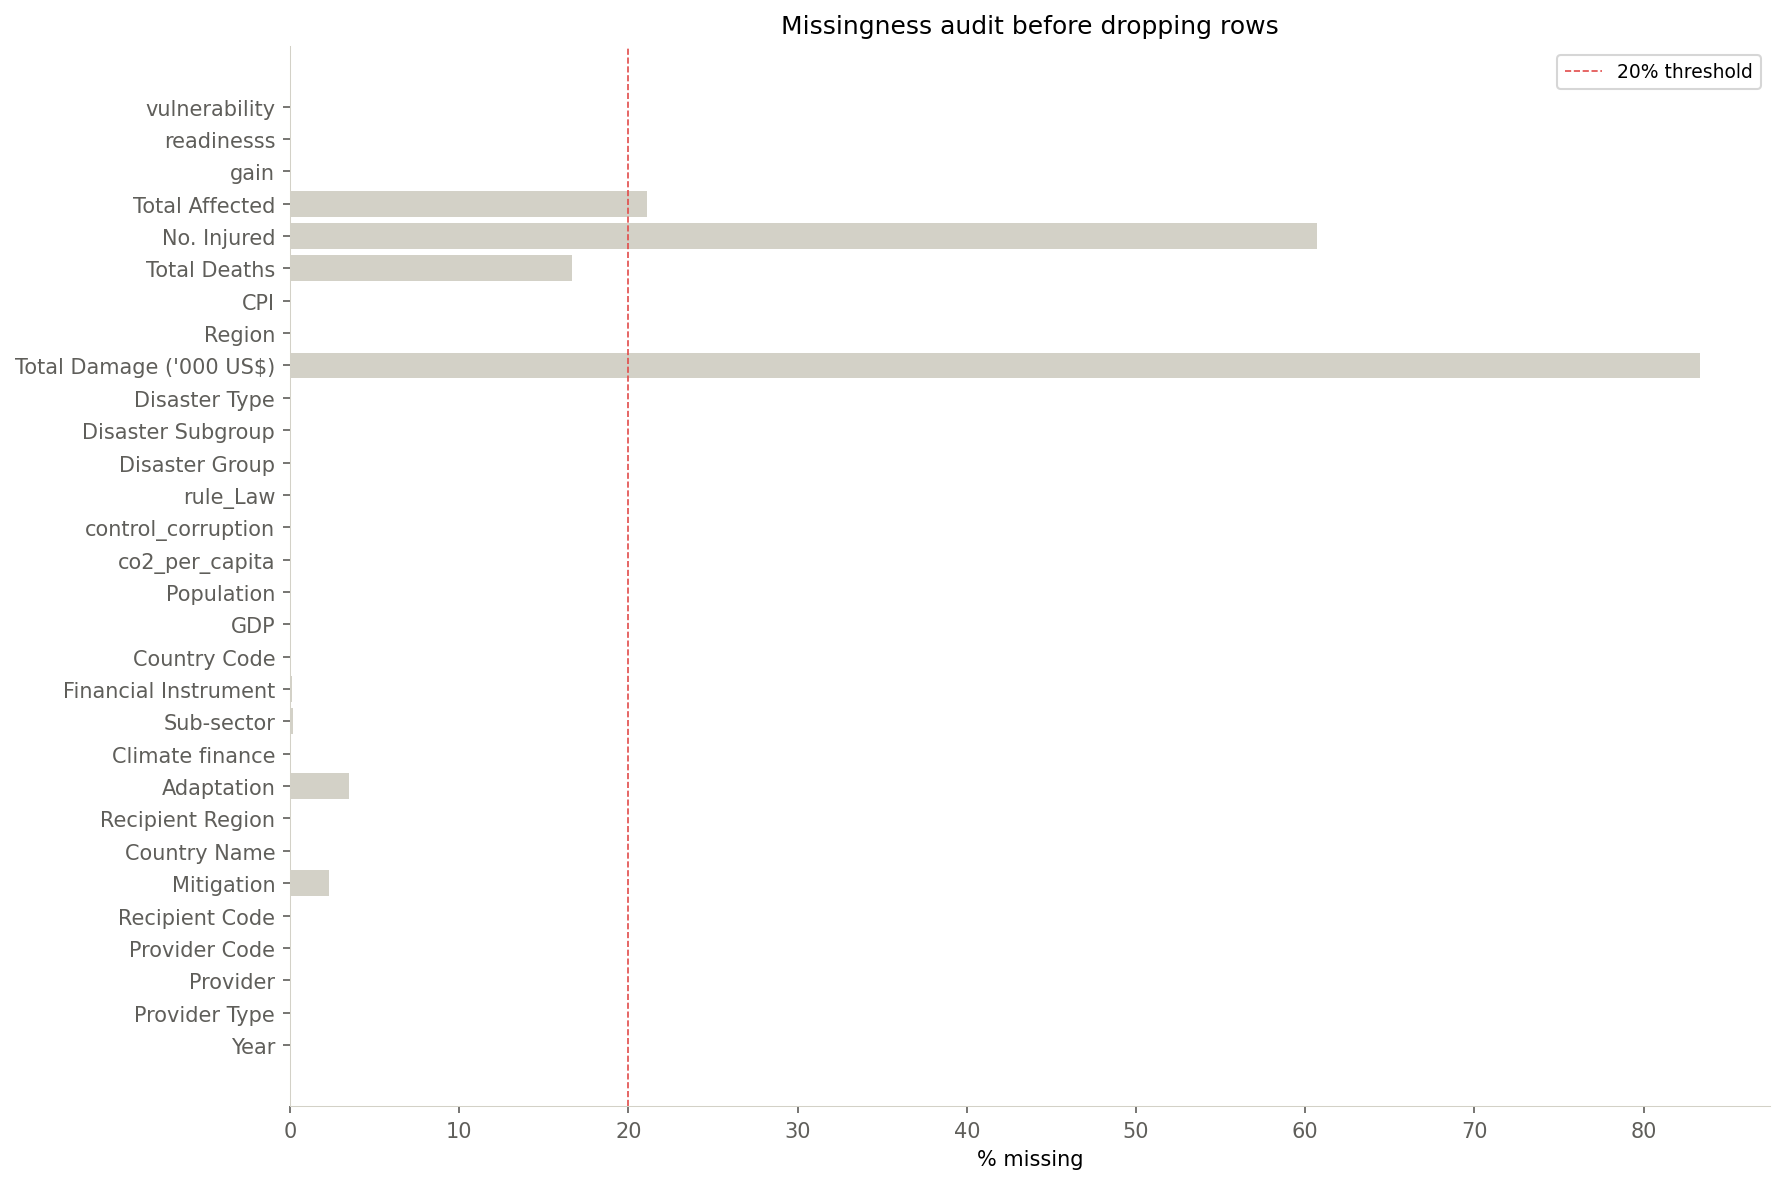

In [109]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(missing.index, missing.values, color=LGRAY)
ax.axvline(20, color=RED, linewidth=0.8, linestyle='--',
           label='20% threshold')
ax.set_xlabel('% missing')
ax.set_title('Missingness audit before dropping rows')
ax.legend(fontsize=9)
plt.tight_layout()
#plt.savefig('figures/00_missingness.png')
plt.show()

In [116]:
df.fillna(0, inplace=True)

In [ ]:
df[df["Total Damage ('000 US$)"].isna()]

In [118]:
df.isna().sum()

Year                       0
Provider Type              0
Provider                   0
Provider Code              0
Recipient Code             0
Mitigation                 0
Country Name               0
Recipient Region           0
Adaptation                 0
Climate finance            0
Sub-sector                 0
Financial Instrument       0
Country Code               0
GDP                        0
Population                 0
co2_per_capita             0
control_corruption         0
rule_Law                   0
Disaster Group             0
Disaster Subgroup          0
Disaster Type              0
Total Damage ('000 US$)    0
Region                     0
CPI                        0
Total Deaths               0
No. Injured                0
Total Affected             0
gain                       0
readinesss                 0
vulnerability              0
dtype: int64

In [105]:
df.to_csv('/Users/macbook/Desktop/Python files/clean_climate', index=False)


In [322]:
df.columns

Index(['Year', 'Provider Type', 'Provider', 'Provider Code', 'Recipient Code',
       'Mitigation', 'Country Name', 'Recipient Region', 'Adaptation',
       'Climate finance', 'Sub-sector', 'Financial Instrument', 'Country Code',
       'GDP', 'Population', 'co2_per_capita', 'control_corruption', 'rule_Law',
       'Disaster Group', 'Disaster Subgroup', 'Disaster Type',
       'Total Damage ('000 US$)', 'Region', 'CPI', 'Total Deaths',
       'No. Injured', 'Total Affected', 'gain', 'readinesss', 'vulnerability'],
      dtype='object')

In [324]:
df['finance_per_capita'] = df['Climate finance']*1e6/df['Population']

<Axes: >

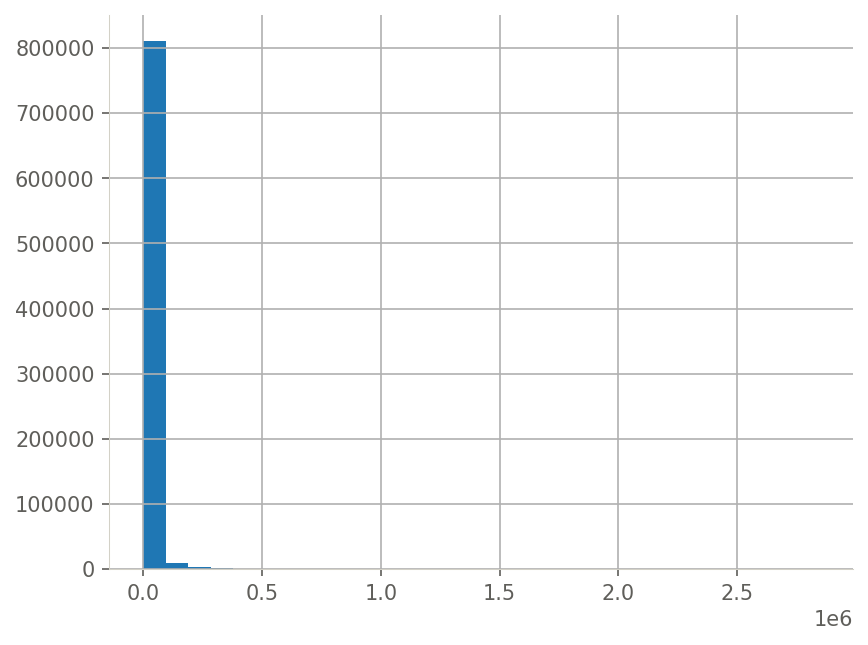

In [326]:
df['Climate finance'].hist(bins=30)

In [328]:
df['log_finance_pc'] = np.log1p(df['finance_per_capita'])

/Users/macbook/anaconda3/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [330]:
df

,Year,Provider Type,Provider,Provider Code,Recipient Code,Mitigation,Country Name,Recipient Region,Adaptation,Climate finance,...,Region,CPI,Total Deaths,No. Injured,Total Affected,gain,readinesss,vulnerability,finance_per_capita,log_finance_pc
0,2000,DAC member,Australia,801,640,17.376195,Sri Lanka,South & Central Asia,0.00,17.376195,...,Asia,54.895152,40.0,0.0,0.0,-0.141169,-0.001506,0.001317,0.900645,0.642193
1,2000,DAC member,Australia,801,640,17.376195,Sri Lanka,South & Central Asia,0.00,17.376195,...,Asia,54.895152,2.0,0.0,113.0,-0.141169,-0.001506,0.001317,0.900645,0.642193
2,2000,DAC member,Australia,801,640,17.376195,Sri Lanka,South & Central Asia,0.00,17.376195,...,Asia,54.895152,5.0,0.0,375000.0,-0.141169,-0.001506,0.001317,0.900645,0.642193
3,2000,DAC member,Australia,801,640,17.376195,Sri Lanka,South & Central Asia,0.00,17.376195,...,Asia,54.895152,3.0,0.0,300000.0,-0.141169,-0.001506,0.001317,0.900645,0.642193
4,2000,DAC member,Australia,801,640,17.376195,Sri Lanka,South & Central Asia,0.00,17.376195,...,Asia,54.895152,2.0,0.0,100000.0,-0.141169,-0.001506,0.001317,0.900645,0.642193
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
827000,2022,Multilateral development bank,WB,905,274,587.200000,Djibouti,Africa,192.16,779.360000,...,Africa,93.294607,0.0,0.0,192168.0,-0.201164,-0.000522,0.003501,685.395077,6.531453
827001,2022,Multilateral development bank,WB,905,274,0.000000,Djibouti,Africa,36.12,36.120000,...,Africa,93.294607,0.0,0.0,192168.0,-0.201164,-0.000522,0.003501,31.765128,3.489365
827002,2022,Multilateral development bank,WB,905,274,0.000000,Djibouti,Africa,8689.12,8689.120000,...,Africa,93.294607,0.0,0.0,192168.0,-0.201164,-0.000522,0.003501,7641.500806,8.941480
827003,2022,Multilateral development bank,WB,905,274,365.120000,Djibouti,Africa,0.00,365.120000,...,Africa,93.294607,0.0,0.0,192168.0,-0.201164,-0.000522,0.003501,321.098658,5.774858


In [332]:
df['physical_risk_index'] = (
    df['vulnerability'] * (1 - df['readinesss'])
)

In [334]:
df['vulnerability_index'] = (
    df['physical_risk_index'] - df['physical_risk_index'].min()
) / (
    df['physical_risk_index'].max() - df['physical_risk_index'].min()
)

In [336]:
df['finance_vs_vulnerability'] = (
    df['finance_per_capita'] / df['physical_risk_index']
)

In [338]:
df['damage_per_capita'] = df["Total Damage ('000 US$)"]/df['Population']

In [340]:
df['institution_quality'] = (df['rule_Law'] + df['control_corruption'])/2

In [342]:
df['log_gdp_pc'] = np.log(df['GDP']/df['Population'])
df['log_co2_pc'] = np.log1p(df['co2_per_capita'])
df['log_damages_pc']= np.log1p(df['damage_per_capita'])
df['log_population'] = np.log(df['Population'])

In [276]:
df

,Year,Provider Type,Provider,Provider Code,Recipient Code,Mitigation,Country Name,Recipient Region,Adaptation,Climate finance,...,finance_per_capita,log_finance_pc,physical_risk_index,damage_per_capita,institution_quality,log_gdp_pc,log_co2_pc,log_damages_pc,log_population,finance_pc_norm
0,2000,DAC member,Australia,801,640,17.376195,Sri Lanka,South & Central Asia,0.0,17.376195,...,0.900645,0.642193,0.502021,0.000000,52.569508,6.757165,0.265215,0.000000,16.775256,0.000031
1,2000,DAC member,Australia,801,640,17.376195,Sri Lanka,South & Central Asia,0.0,17.376195,...,0.900645,0.642193,0.502021,0.000000,52.569508,6.757165,0.265215,0.000000,16.775256,0.000031
2,2000,DAC member,Australia,801,640,17.376195,Sri Lanka,South & Central Asia,0.0,17.376195,...,0.900645,0.642193,0.502021,0.000000,52.569508,6.757165,0.265215,0.000000,16.775256,0.000031
3,2000,DAC member,Australia,801,640,17.376195,Sri Lanka,South & Central Asia,0.0,17.376195,...,0.900645,0.642193,0.502021,0.000155,52.569508,6.757165,0.265215,0.000155,16.775256,0.000031
4,2000,DAC member,Australia,801,640,17.376195,Sri Lanka,South & Central Asia,0.0,17.376195,...,0.900645,0.642193,0.502021,0.000000,52.569508,6.757165,0.265215,0.000000,16.775256,0.000031
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
830726,2017,Other multilateral,Adaptation Fund,1012,377,0.000000,Antigua and Barbuda,America,1994.0,1994.000000,...,22040.942654,10.000702,0.363789,2.763408,60.033059,9.738951,0.165781,1.325325,11.412751,0.018105
830727,2017,Other multilateral,Adaptation Fund,1012,377,0.000000,Antigua and Barbuda,America,997.0,997.000000,...,11020.471327,9.307601,0.363789,2.763408,60.033059,9.738951,0.165781,1.325325,11.412751,0.009068
830728,2017,Other multilateral,Adaptation Fund,1012,377,0.000000,Antigua and Barbuda,America,2492.5,2492.500000,...,27551.178317,10.223837,0.363789,2.763408,60.033059,9.738951,0.165781,1.325325,11.412751,0.022623
830729,2017,Other multilateral,Adaptation Fund,1012,377,0.000000,Antigua and Barbuda,America,2492.5,2492.500000,...,27551.178317,10.223837,0.363789,2.763408,60.033059,9.738951,0.165781,1.325325,11.412751,0.022623


In [347]:
FEATURES = [
    'physical_risk_index',   # your key variable of interest
    'log_gdp_pc',            # economic capacity
    'log_damages_pc',        # realised climate losses
    'institution_quality', # governance
    'CPI',                   # Corruption Index
    'log_co2_pc',            # emissions profile
    'log_population',        # country size
]

TARGET = 'log_finance_pc'

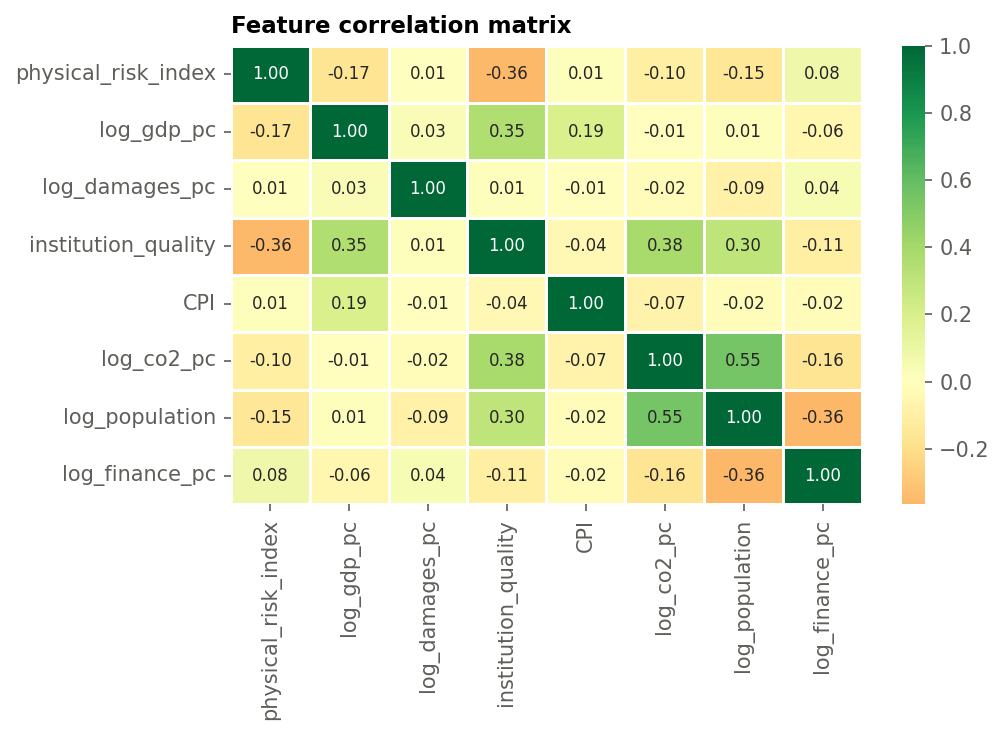

In [467]:
corr_cols = FEATURES + [TARGET]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
#mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, ax=ax,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 8})
ax.set_title('Feature correlation matrix', fontsize=11,
             fontweight='bold', loc='left')
plt.tight_layout()
plt.savefig('/Users/macbook/Desktop/Poster images/heatmap.png')
plt.show()

In [351]:
df

,Year,Provider Type,Provider,Provider Code,Recipient Code,Mitigation,Country Name,Recipient Region,Adaptation,Climate finance,...,log_finance_pc,physical_risk_index,vulnerability_index,finance_vs_vulnerability,damage_per_capita,institution_quality,log_gdp_pc,log_co2_pc,log_damages_pc,log_population
0,2000,DAC member,Australia,801,640,17.376195,Sri Lanka,South & Central Asia,0.00,17.376195,...,0.642193,0.001319,0.502021,6.827061e+02,0.000000,52.569508,6.757165,0.265215,0.000000,16.775256
1,2000,DAC member,Australia,801,640,17.376195,Sri Lanka,South & Central Asia,0.00,17.376195,...,0.642193,0.001319,0.502021,6.827061e+02,0.000000,52.569508,6.757165,0.265215,0.000000,16.775256
2,2000,DAC member,Australia,801,640,17.376195,Sri Lanka,South & Central Asia,0.00,17.376195,...,0.642193,0.001319,0.502021,6.827061e+02,0.000000,52.569508,6.757165,0.265215,0.000000,16.775256
3,2000,DAC member,Australia,801,640,17.376195,Sri Lanka,South & Central Asia,0.00,17.376195,...,0.642193,0.001319,0.502021,6.827061e+02,0.000155,52.569508,6.757165,0.265215,0.000155,16.775256
4,2000,DAC member,Australia,801,640,17.376195,Sri Lanka,South & Central Asia,0.00,17.376195,...,0.642193,0.001319,0.502021,6.827061e+02,0.000000,52.569508,6.757165,0.265215,0.000000,16.775256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
827000,2022,Multilateral development bank,WB,905,274,587.200000,Djibouti,Africa,192.16,779.360000,...,6.531453,0.003503,0.629756,1.956733e+05,0.000000,34.421222,8.049829,0.229165,0.000000,13.943988
827001,2022,Multilateral development bank,WB,905,274,0.000000,Djibouti,Africa,36.12,36.120000,...,3.489365,0.003503,0.629756,9.068618e+03,0.000000,34.421222,8.049829,0.229165,0.000000,13.943988
827002,2022,Multilateral development bank,WB,905,274,0.000000,Djibouti,Africa,8689.12,8689.120000,...,8.941480,0.003503,0.629756,2.181570e+06,0.000000,34.421222,8.049829,0.229165,0.000000,13.943988
827003,2022,Multilateral development bank,WB,905,274,365.120000,Djibouti,Africa,0.00,365.120000,...,5.774858,0.003503,0.629756,9.167037e+04,0.000000,34.421222,8.049829,0.229165,0.000000,13.943988


In [353]:
df.fillna(0, inplace=True)

In [355]:
X = df[FEATURES]
y = df[TARGET]

In [359]:
map = df.groupby(['Country Code', 'Country Name'])[FEATURES + [TARGET, 'finance_per_capita', 'Climate finance', 
                                                              'Population', 'vulnerability_index']].mean().reset_index()


In [363]:
map[['Country Code','physical_risk_index', 'finance_per_capita', 'Climate finance', 'Population']]

,Country Code,physical_risk_index,finance_per_capita,Climate finance,Population
0,AFG,-0.000429,130.862825,4472.836097,3.534604e+07
1,AGO,-0.001143,152.371534,4830.577637,2.923287e+07
2,ALB,-0.005953,1691.328031,4458.360483,2.674331e+06
3,ARG,0.000075,276.504150,12350.236444,4.341611e+07
4,ARM,-0.002433,840.308489,2505.853201,2.973798e+06
...,...,...,...,...,...
110,VUT,-0.004718,2285.497043,661.365562,3.053528e+05
111,WSM,0.005859,6929.686892,1409.460617,2.041235e+05
112,ZAF,-0.000603,97.260211,5790.861411,5.831709e+07
113,ZMB,-0.001782,106.221789,1856.339514,1.845422e+07


In [365]:
df['Country Name'].value_counts()

Country Name
India                  147767
Indonesia              103695
Philippines             54236
Viet Nam                34479
Brazil                  33773
                        ...  
Eritrea                     9
Antigua and Barbuda         9
Oman                        8
Trinidad and Tobago         5
Grenada                     3
Name: count, Length: 115, dtype: int64

In [367]:
gain_main

,Country Code,Country Name,gain,readinesss,vulnerability
0,AFG,Afghanistan,0.115980,0.001890,-0.000429
1,ALB,Albania,0.418055,0.002394,-0.005967
2,DZA,Algeria,0.363887,0.004706,-0.002571
3,AND,Andorra,NaN,0.026148,NaN
4,AGO,Angola,0.259735,0.004047,-0.001147
...,...,...,...,...,...
187,VEN,"Venezuela, Bolivarian Republic o",0.053636,0.000593,-0.000479
188,VNM,Viet Nam,0.268948,0.005000,-0.000379
189,YEM,Yemen,-0.123201,-0.000463,0.002001
190,ZMB,Zambia,0.156066,0.001337,-0.001784


In [369]:
gain_main.fillna(0, inplace=True)

In [371]:
gain_main['Climate_vulnerability_index'] = (gain_main['vulnerability'] * (1 - gain_main['readinesss']))

In [373]:
gain_main['Climate_vulnerability_index'] = (
    gain_main['Climate_vulnerability_index'] - gain_main['Climate_vulnerability_index'].min()
) / (
    gain_main['Climate_vulnerability_index'].max() - gain_main['Climate_vulnerability_index'].min()
)

In [375]:
import plotly.express as px


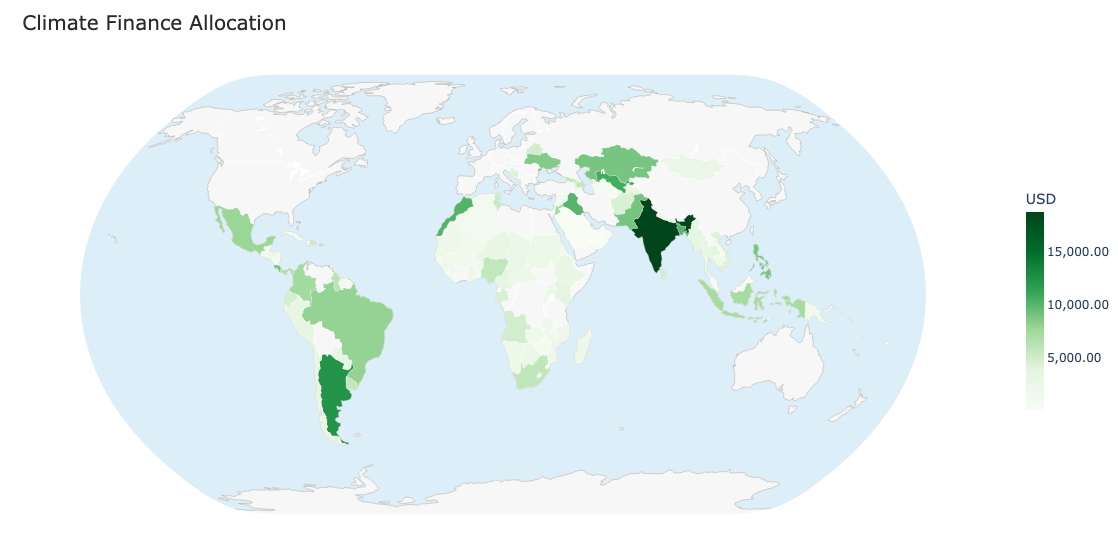

In [377]:
fig = px.choropleth(
    map,
    locations='Country Code',
    color='Climate finance',

    hover_name='Country Name',
    hover_data={
        'Climate finance': ':,.2f',
        'log_finance_pc': False
    },

    # perceptually smoother scale
    color_continuous_scale=[
        [0.0, '#f7fcf5'],
        [0.2, '#e5f5e0'],
        [0.4, '#a1d99b'],
        [0.6, '#31a354'],
        [0.8, '#006d2c'],
        [1.0, '#00441b'],
    ],

    title='Climate Finance Allocation',
)

# ── 3. Better visual hierarchy ────────────────────────────────
fig.update_traces(
    marker_line_color='rgba(255,255,255,0.6)',
    marker_line_width=0.4
)

# ── 4. Layout polish ──────────────────────────────────────────
fig.update_layout(
    width=1100,
    height=550,

    title=dict(
        text='Climate Finance Allocation',
        x=0.02,
        font=dict(size=20, color='#2b2b2b')
    ),

    coloraxis_colorbar=dict(
        title='USD',
        thickness=18,
        len=0.5,
        tickformat=',.2f',
        outlinewidth=0
    ),

    geo=dict(
        showframe=False,

        showcountries=True,
        countrycolor='rgba(255,255,255,0.6)',

        showcoastlines=True,
        coastlinecolor='#aaaaaa',
        coastlinewidth=0.6,

        showland=True,
        landcolor='#f7f7f7',

        showocean=True,
        oceancolor='#dceef7',

        projection_type='natural earth'
    ),

    paper_bgcolor='white',
    margin=dict(l=10, r=10, t=60, b=10),
)
fig.show()

In [379]:
gain_main

,Country Code,Country Name,gain,readinesss,vulnerability,Climate_vulnerability_index
0,AFG,Afghanistan,0.115980,0.001890,-0.000429,0.399772
1,ALB,Albania,0.418055,0.002394,-0.005967,0.076615
2,DZA,Algeria,0.363887,0.004706,-0.002571,0.275132
3,AND,Andorra,0.000000,0.026148,0.000000,0.424847
4,AGO,Angola,0.259735,0.004047,-0.001147,0.357998
...,...,...,...,...,...,...
187,VEN,"Venezuela, Bolivarian Republic o",0.053636,0.000593,-0.000479,0.396820
188,VNM,Viet Nam,0.268948,0.005000,-0.000379,0.402789
189,YEM,Yemen,-0.123201,-0.000463,0.002001,0.541931
190,ZMB,Zambia,0.156066,0.001337,-0.001784,0.320630


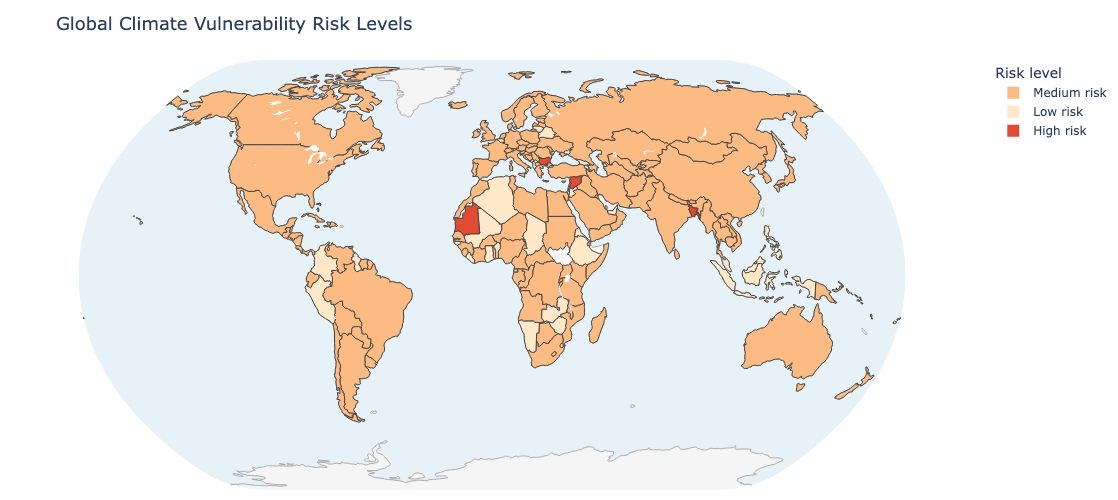

In [381]:
# ── 1. Create 3-level risk categories ──────────────────────────
gain_main['risk_category'] = pd.cut(
    gain_main['Climate_vulnerability_index'],
    bins=[0, 0.33, 0.66, 1],
    labels=['Low risk', 'Medium risk', 'High risk'],
    include_lowest=True
)

# Ensure proper legend order
gain_main['risk_category'] = pd.Categorical(
    gain_main['risk_category'],
    categories=['Low risk', 'Medium risk', 'High risk'],
    ordered=True
)

# ── 2. Define discrete color palette ───────────────────────────
color_map = {
    'Low risk':    '#fee8c8',
    'Medium risk': '#fdbb84',
    'High risk':   '#e34a33'
}

# ── 3. Create choropleth map ───────────────────────────────────
fig = px.choropleth(
    gain_main,
    locations='Country Code',
    color='risk_category',
    hover_name='Country Name',
    hover_data={'Climate_vulnerability_index': ':.2f'},
    color_discrete_map=color_map,
    title='Global Climate Vulnerability Risk Levels'
)

# ── 4. Style layout ────────────────────────────────────────────
fig.update_layout(
    width=1000,
    height=500,
    title_font_size=18,
    title_x=0.05,

    legend_title_text='Risk level',

    geo=dict(
        showframe=False,
        showcountries=True,
        countrycolor='rgba(255,255,255,0.6)',
        countrywidth=0.4,

        showcoastlines=True,
        coastlinecolor='#aaaaaa',

        showland=True,
        landcolor='#f5f5f5',

        showocean=True,
        oceancolor='#e6f2f7',

        projection_type='natural earth',
    ),

    paper_bgcolor='white',
    margin=dict(l=10, r=10, t=60, b=10),
)

fig.show()

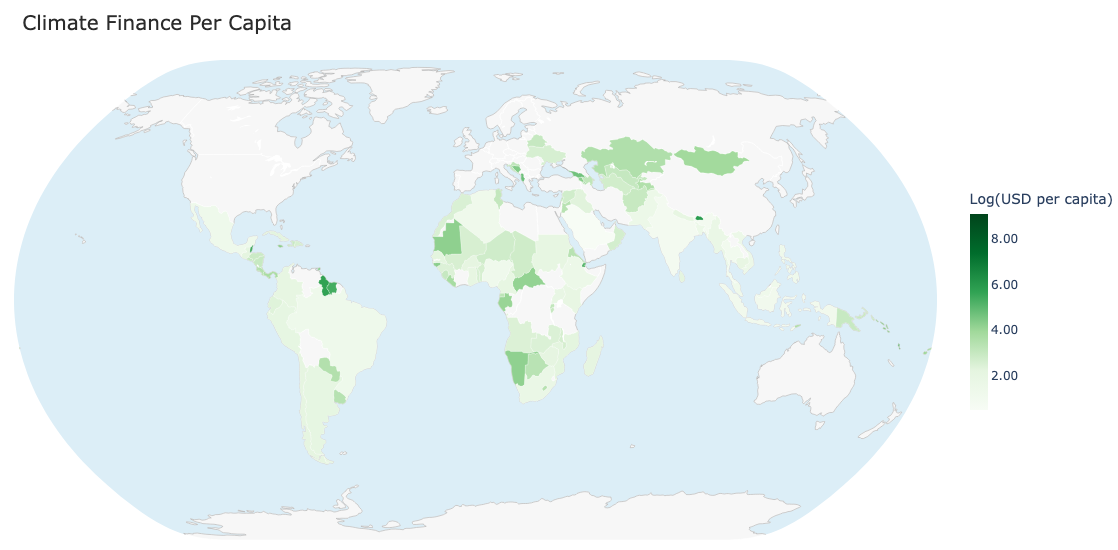

In [383]:
fig = px.choropleth(
    map,
    locations='Country Code',
    color='log_finance_pc',

    hover_name='Country Name',
    hover_data={
        'finance_per_capita': ':,.2f',
        'log_finance_pc': False
    },

    # perceptually smoother scale
    color_continuous_scale=[
        [0.0, '#f7fcf5'],
        [0.2, '#e5f5e0'],
        [0.4, '#a1d99b'],
        [0.6, '#31a354'],
        [0.8, '#006d2c'],
        [1.0, '#00441b'],
    ],

    title='Climate Finance Per Capita',
)

# ── 3. Better visual hierarchy ────────────────────────────────
fig.update_traces(
    marker_line_color='rgba(255,255,255,0.6)',
    marker_line_width=0.4
)

# ── 4. Layout polish ──────────────────────────────────────────
fig.update_layout(
    width=1100,
    height=550,

    title=dict(
        text='Climate Finance Per Capita',
        x=0.02,
        font=dict(size=20, color='#2b2b2b')
    ),

    coloraxis_colorbar=dict(
        title='Log(USD per capita)',
        thickness=18,
        len=0.5,
        tickformat=',.2f',
        outlinewidth=0
    ),

    geo=dict(
        showframe=False,

        showcountries=True,
        countrycolor='rgba(255,255,255,0.6)',

        showcoastlines=True,
        coastlinecolor='#aaaaaa',
        coastlinewidth=0.6,

        showland=True,
        landcolor='#f7f7f7',

        showocean=True,
        oceancolor='#dceef7',

        projection_type='natural earth'
    ),

    paper_bgcolor='white',
    margin=dict(l=10, r=10, t=60, b=10),
)

fig.show()

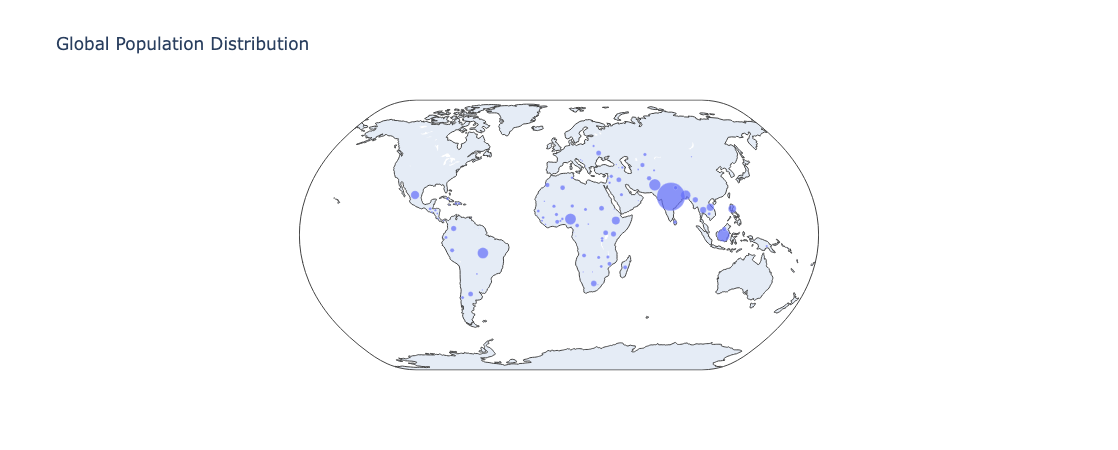

In [491]:
fig = px.scatter_geo(
    map,
    locations='Country Code',

    size='Population',  # 👈 key
    hover_name='Country Name',
    hover_data={'Population': ':,.0f'},

    projection='natural earth',
    title='Global Population Distribution'
)
fig.update_traces(
    marker_line_color='rgba(255,255,255,0.6)',
    marker_line_width=0.4
)

fig.update_layout(
    width=800,
    height=450,
)
fig.show()

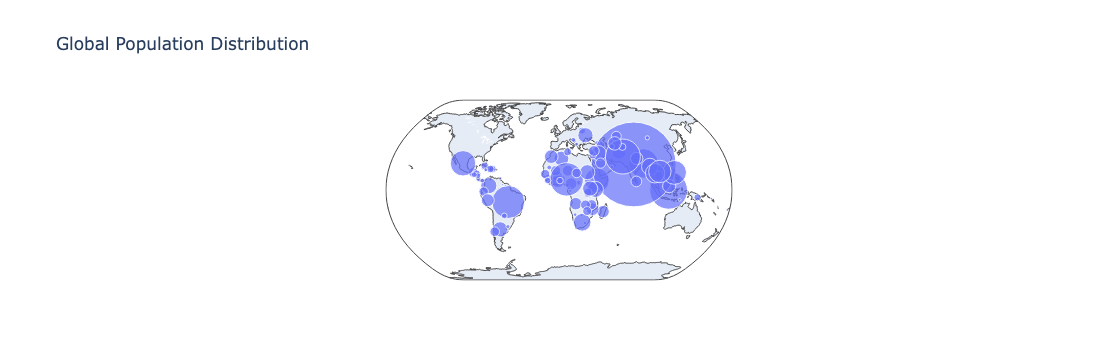

In [387]:
fig = px.scatter_geo(
    map,
    locations='Country Code',

    size='Population',
    size_max=60,  # 👈 increase this (default ~20)

    hover_name='Country Name',
    hover_data={'Population': ':,.0f'},

    projection='natural earth',
    title='Global Population Distribution'
)

fig.show()

In [389]:
df.columns

Index(['Year', 'Provider Type', 'Provider', 'Provider Code', 'Recipient Code',
       'Mitigation', 'Country Name', 'Recipient Region', 'Adaptation',
       'Climate finance', 'Sub-sector', 'Financial Instrument', 'Country Code',
       'GDP', 'Population', 'co2_per_capita', 'control_corruption', 'rule_Law',
       'Disaster Group', 'Disaster Subgroup', 'Disaster Type',
       'Total Damage ('000 US$)', 'Region', 'CPI', 'Total Deaths',
       'No. Injured', 'Total Affected', 'gain', 'readinesss', 'vulnerability',
       'finance_per_capita', 'log_finance_pc', 'physical_risk_index',
       'vulnerability_index', 'finance_vs_vulnerability', 'damage_per_capita',
       'institution_quality', 'log_gdp_pc', 'log_co2_pc', 'log_damages_pc',
       'log_population'],
      dtype='object')

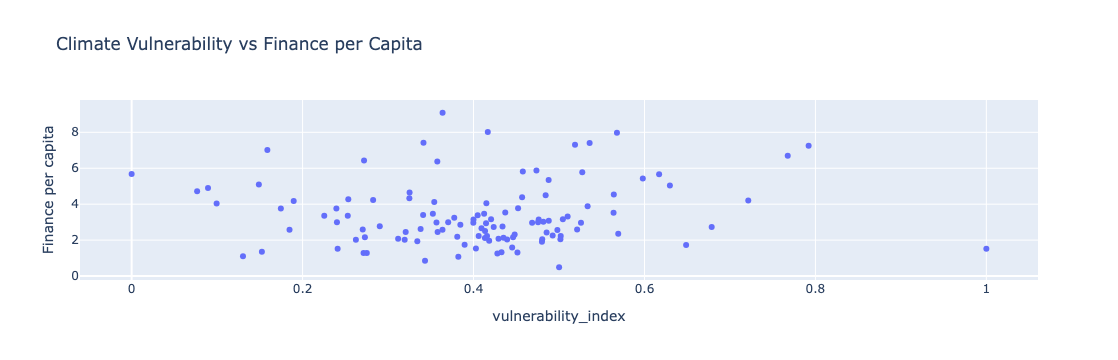

In [391]:
fig = px.scatter(
    map,
    x='vulnerability_index',
    y='log_finance_pc',

    hover_name='Country Name',
    hover_data={
        'vulnerability_index': ':.2f',
        'finance_per_capita': ':,.2f'
    },

    title='Climate Vulnerability vs Finance per Capita',
    labels={
        'Climate_vulnerability_index': 'Vulnerability',
        'log_finance_pc': 'Finance per capita'
    }
)

fig.show()

In [393]:
finance_loss = df.groupby(['Year'])[["Total Damage ('000 US$)", 'Climate finance']].sum().reset_index()

In [395]:
finance_loss

,Year,Total Damage ('000 US$),Climate finance
0,2000,5.302158e+07,3.277861e+06
1,2002,2.792201e+07,5.894010e+06
2,2003,8.720991e+07,5.562052e+07
3,2004,2.049753e+08,4.573540e+07
4,2005,4.389494e+08,3.818306e+07
5,2006,2.687771e+08,4.523229e+07
6,2007,2.845720e+08,3.376751e+07
7,2008,2.728900e+08,7.519550e+07
8,2009,5.292759e+08,7.793162e+07
9,2010,3.521161e+09,1.982504e+08


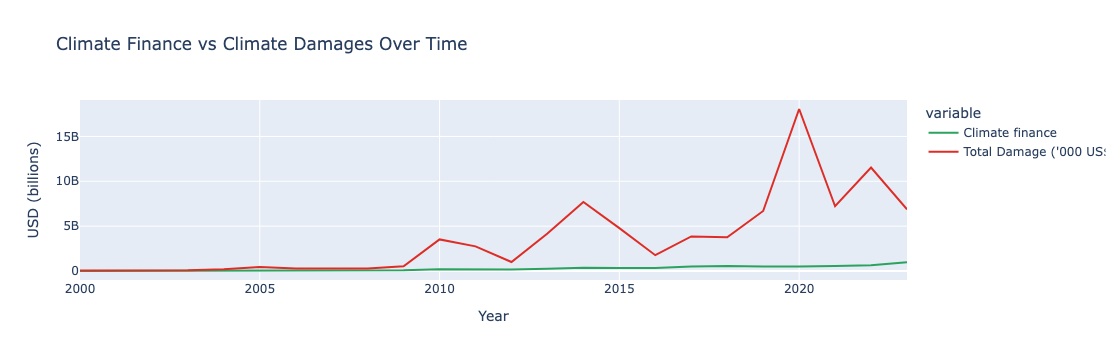

In [397]:
fig = px.line(
    finance_loss,
    x='Year',
    y=['Climate finance', "Total Damage ('000 US$)"],

    color_discrete_map={
        'Climate finance': '#2ca25f',   # green
        "Total Damage ('000 US$)": '#de2d26'    # red
    },

    title='Climate Finance vs Climate Damages Over Time'
)

fig.update_layout(
    yaxis_title='USD (billions)',
    xaxis_title='Year'
)

fig.show()

In [399]:
df [df['log_finance_pc'] < 1]

,Year,Provider Type,Provider,Provider Code,Recipient Code,Mitigation,Country Name,Recipient Region,Adaptation,Climate finance,...,log_finance_pc,physical_risk_index,vulnerability_index,finance_vs_vulnerability,damage_per_capita,institution_quality,log_gdp_pc,log_co2_pc,log_damages_pc,log_population
0,2000,DAC member,Australia,801,640,17.376195,Sri Lanka,South & Central Asia,0.000000,17.376195,...,0.642193,0.001319,0.502021,682.706126,0.000000,52.569508,6.757165,0.265215,0.000000,16.775256
1,2000,DAC member,Australia,801,640,17.376195,Sri Lanka,South & Central Asia,0.000000,17.376195,...,0.642193,0.001319,0.502021,682.706126,0.000000,52.569508,6.757165,0.265215,0.000000,16.775256
2,2000,DAC member,Australia,801,640,17.376195,Sri Lanka,South & Central Asia,0.000000,17.376195,...,0.642193,0.001319,0.502021,682.706126,0.000000,52.569508,6.757165,0.265215,0.000000,16.775256
3,2000,DAC member,Australia,801,640,17.376195,Sri Lanka,South & Central Asia,0.000000,17.376195,...,0.642193,0.001319,0.502021,682.706126,0.000155,52.569508,6.757165,0.265215,0.000155,16.775256
4,2000,DAC member,Australia,801,640,17.376195,Sri Lanka,South & Central Asia,0.000000,17.376195,...,0.642193,0.001319,0.502021,682.706126,0.000000,52.569508,6.757165,0.265215,0.000000,16.775256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
826937,2021,DAC member,Japan,701,274,0.000000,Djibouti,South of Sahara,0.133621,0.133621,...,0.112589,0.003503,0.629756,34.022407,0.000000,34.340855,8.014968,0.228042,0.000000,13.929953
826947,2022,DAC member,France,4,274,0.509927,Djibouti,South of Sahara,0.509927,0.509927,...,0.370492,0.003503,0.629756,128.027050,0.000000,34.421222,8.049829,0.229165,0.000000,13.943988
826958,2022,DAC member,Japan,701,274,0.000114,Djibouti,South of Sahara,0.000114,0.000114,...,0.000100,0.003503,0.629756,0.028655,0.000000,34.421222,8.049829,0.229165,0.000000,13.943988
826976,2022,DAC member,Canada,301,274,0.430207,Djibouti,South of Sahara,0.000000,0.430207,...,0.320878,0.003503,0.629756,108.011620,0.000000,34.421222,8.049829,0.229165,0.000000,13.943988


In [401]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() # assign scaler to a variable 


In [403]:
from sklearn.model_selection import train_test_split 

X_train, X_test, y_train, y_test = train_test_split (X,y,test_size = 0.2, random_state=42)

In [405]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold

In [407]:
Linear = LinearRegression()

RFR = RandomForestRegressor(n_estimators = 300,   # number of trees
        max_depth    = 6,     # how deep each tree can go
        random_state = 42     # for reproducibility
    )

In [419]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform (X_test)

In [429]:
Linear.fit(X_train, y_train)

y_linear_pred = Linear.predict(X_test) # prediction

In [431]:
y_linear_pred

array([1.85738895, 0.78301399, 0.68758029, ..., 1.15589289, 1.71522851,
       0.66282341])

In [433]:
r2_linear = Linear.score(X_test, y_test)

In [437]:
from sklearn.metrics import r2_score, mean_squared_error

r2 = Linear.score(X_test, y_test)
r2

0.1374950162055154

In [439]:
model = RFR.fit(X_train, y_train)

In [441]:
predicts = RFR.predict(X_test)
predicts

array([2.06904714, 0.90374834, 0.92667381, ..., 1.21390795, 1.10466545,
       0.86742811])

In [443]:
r2_rand = model.score(X_test, y_test)

In [598]:
pip install xgboost

  Obtaining dependency information for xgboost from https://files.pythonhosted.org/packages/2d/49/6e4cdd877c24adf56cb3586bc96d93d4dcd780b5ea1efb32e1ee0de08bae/xgboost-3.2.0-py3-none-macosx_10_15_x86_64.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 9.0 MB/s eta 0:00:00:00:0100:01
Note: you may need to restart the kernel to use updated packages.


In [445]:
from xgboost import XGBRegressor

model_1 = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

model_xg = model_1.fit(X_train, y_train)

In [447]:
r2_xg = model_1.score(X_test, y_test)

In [449]:
r2_xg

0.17678375549194425

In [451]:
df_1 = crdf_sel.merge(indicator_final, on=['Year', 'Country Name']).merge(emdat_sel, on=['Year', 'Country Code', 'Country Name']).merge(
    gain_main, on=['Country Code', 'Country Name'])

In [453]:
df_1

,Year,Provider Type,Provider,Provider Code,Recipient Code,Mitigation,Country Name,Recipient Region,Adaptation,Climate finance,...,Region,CPI,Total Deaths,No. Injured,Total Affected,gain,readinesss,vulnerability,Climate_vulnerability_index,risk_category
0,2000,DAC member,Australia,801,640,17.376195,Sri Lanka,South & Central Asia,0.00,17.376195,...,Asia,54.895152,40.0,NaN,NaN,-0.141169,-0.001506,0.001317,0.502021,Medium risk
1,2000,DAC member,Australia,801,640,17.376195,Sri Lanka,South & Central Asia,0.00,17.376195,...,Asia,54.895152,2.0,NaN,113.0,-0.141169,-0.001506,0.001317,0.502021,Medium risk
2,2000,DAC member,Australia,801,640,17.376195,Sri Lanka,South & Central Asia,0.00,17.376195,...,Asia,54.895152,5.0,NaN,375000.0,-0.141169,-0.001506,0.001317,0.502021,Medium risk
3,2000,DAC member,Australia,801,640,17.376195,Sri Lanka,South & Central Asia,0.00,17.376195,...,Asia,54.895152,3.0,NaN,300000.0,-0.141169,-0.001506,0.001317,0.502021,Medium risk
4,2000,DAC member,Australia,801,640,17.376195,Sri Lanka,South & Central Asia,0.00,17.376195,...,Asia,54.895152,2.0,NaN,100000.0,-0.141169,-0.001506,0.001317,0.502021,Medium risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
827000,2022,Multilateral development bank,WB,905,274,587.200000,Djibouti,Africa,192.16,779.360000,...,Africa,93.294607,NaN,NaN,192168.0,-0.201164,-0.000522,0.003501,0.629756,Medium risk
827001,2022,Multilateral development bank,WB,905,274,0.000000,Djibouti,Africa,36.12,36.120000,...,Africa,93.294607,NaN,NaN,192168.0,-0.201164,-0.000522,0.003501,0.629756,Medium risk
827002,2022,Multilateral development bank,WB,905,274,0.000000,Djibouti,Africa,8689.12,8689.120000,...,Africa,93.294607,NaN,NaN,192168.0,-0.201164,-0.000522,0.003501,0.629756,Medium risk
827003,2022,Multilateral development bank,WB,905,274,365.120000,Djibouti,Africa,0.00,365.120000,...,Africa,93.294607,NaN,NaN,192168.0,-0.201164,-0.000522,0.003501,0.629756,Medium risk


In [455]:
Model_outcome = pd.DataFrame({'Model':['Linear Regression', 'Random Forest', 'XGBoost'], 'R2 Score':[r2_linear*100, r2_rand*100, r2_xg*100]})

In [457]:
Model_outcome

,Model,R2 Score
0,Linear Regression,13.749502
1,Random Forest,16.645836
2,XGBoost,17.678376


In [459]:
import shap

In [461]:
explainer = shap.Explainer(model_xg.predict, X_train)
shap_values = explainer(X_test)


ExactExplainer explainer: 165402it [38:26, 71.48it/s]                           


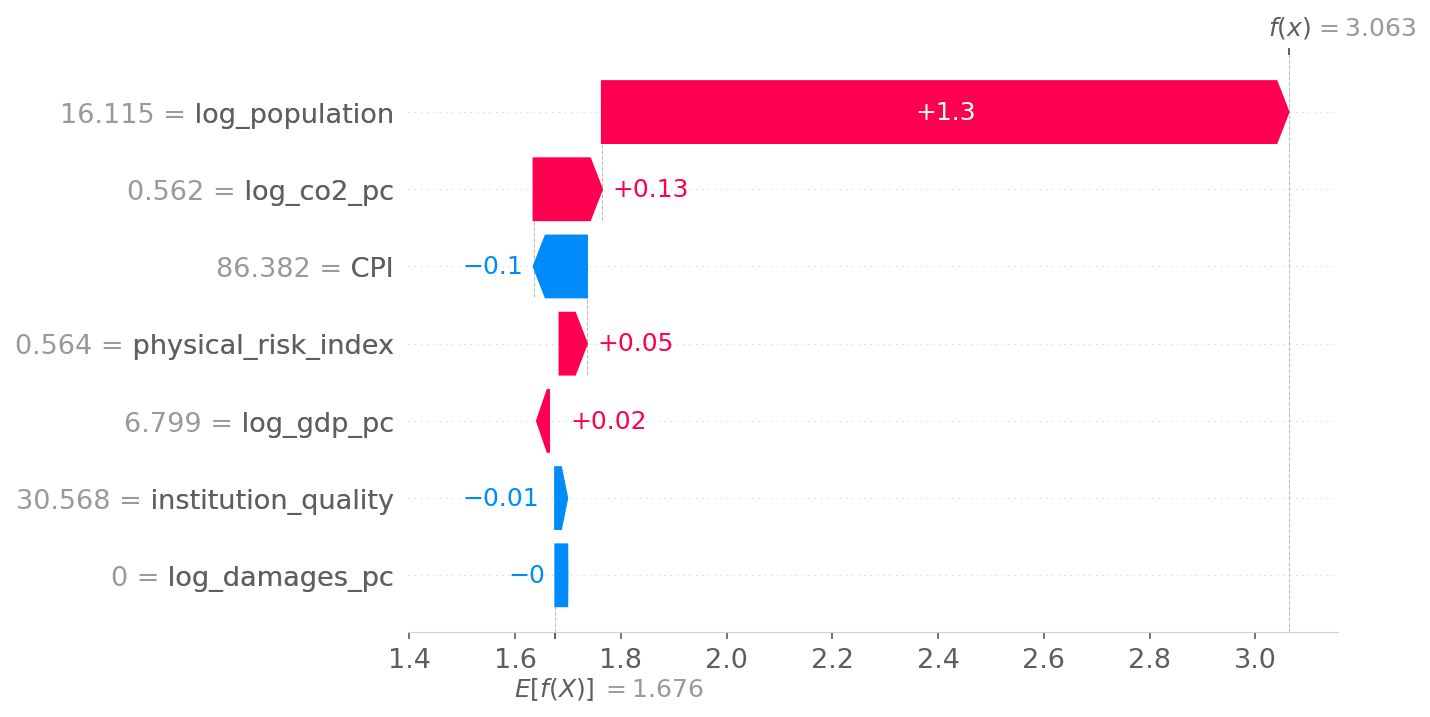

<Figure size 960x720 with 0 Axes>

In [799]:
shap.plots.waterfall(shap_values[0])
plt.savefig('/Users/macbook/Desktop/Poster images/shap.png')


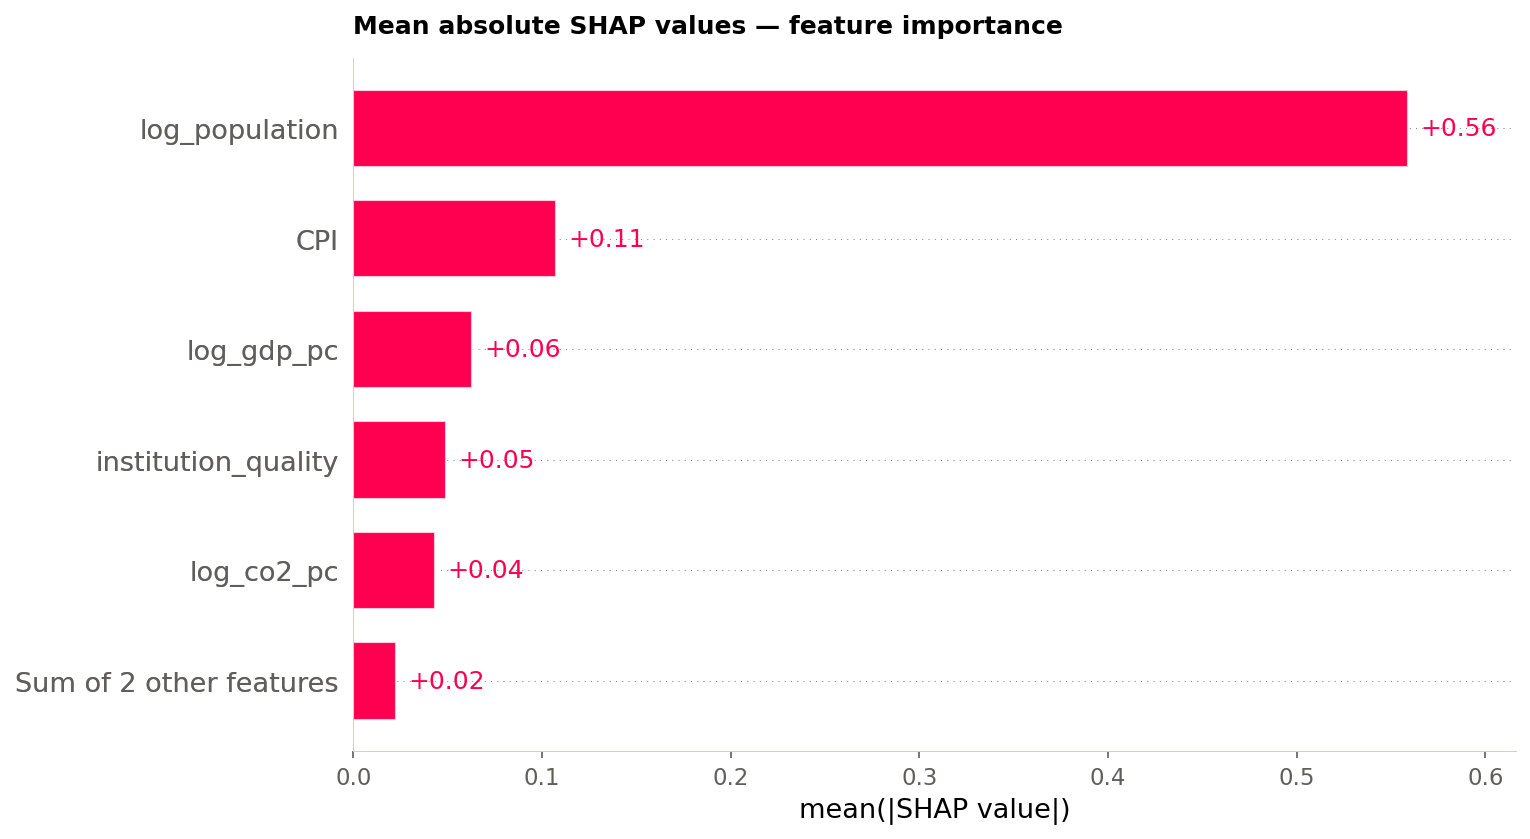

<Figure size 960x720 with 0 Axes>

In [465]:
shap.plots.bar(shap_values, show=False, max_display=6)

fig = plt.gcf()
fig.set_size_inches(10, 6)
plt.title('Mean absolute SHAP values — feature importance',
          fontsize=12, fontweight='bold', loc='left', pad=12)

fig.savefig('/Users/macbook/Desktop/Poster images/shap_bar.png',
            dpi=300,
            bbox_inches='tight',
            facecolor='white')
plt.show()

plt.savefig('/Users/macbook/Desktop/Poster images/shap_2.png')

In [663]:
crdf_sel

,Year,Provider Type,Provider,Provider Code,Recipient Code,Mitigation,Country Name,Recipient Region,Adaptation,Climate finance,Sub-sector,Financial Instrument
0,2000,DAC member,Finland,18,489,5.424927e+02,"South America, regional",South America,0.000000,5.424927e+02,Forestry policy and administrative management,Grant
1,2000,DAC member,Finland,18,287,1.410481e+02,Burkina Faso,South of Sahara,0.000000,1.410481e+02,Forestry development,Grant
2,2000,DAC member,Australia,801,854,1.100492e+01,Vanuatu,Oceania,0.000000,1.100492e+01,Forestry policy and administrative management,Grant
3,2000,DAC member,Australia,801,640,1.737619e+01,Sri Lanka,South & Central Asia,0.000000,1.737619e+01,Forestry development,Grant
4,2000,DAC member,Australia,801,640,6.028370e+00,Sri Lanka,South & Central Asia,0.000000,6.028370e+00,Agricultural education/training,Grant
...,...,...,...,...,...,...,...,...,...,...,...,...
222718,2023,Other multilateral,IMF-RST,1058,256,NaN,Mauritania,Africa,19823.307930,1.982331e+04,General budget support-related aid,Debt instrument
222719,2023,Other multilateral,IMF-RST,1058,256,1.982331e+04,Mauritania,Africa,19823.307930,1.982331e+04,General budget support-related aid,Debt instrument
222720,2023,Other multilateral,IMF-RST,1058,256,NaN,Mauritania,Africa,19849.988020,1.984999e+04,General budget support-related aid,Debt instrument
222721,2023,Multilateral development bank,IFC,903,998,6.328256e+06,"Developing countries, unspecified",Unspecified,136816.930396,6.413919e+06,NaN,NaN


In [669]:
crdf_sel.groupby('Year')['Climate finance'].sum()

Year
2000    5.013284e+05
2001    1.571647e+06
2002    1.442095e+06
2003    3.363012e+06
2004    3.166008e+06
2005    4.060241e+06
2006    4.062644e+06
2007    4.067276e+06
2008    8.880702e+06
2009    1.136217e+07
2010    2.724270e+07
2011    2.399556e+07
2012    2.842720e+07
2013    4.425611e+07
2014    5.113428e+07
2015    4.939872e+07
2016    5.598686e+07
2017    7.005212e+07
2018    7.126320e+07
2019    8.290455e+07
2020    9.677556e+07
2021    9.802697e+07
2022    1.297990e+08
2023    1.451100e+08
Name: Climate finance, dtype: float64

In [661]:
1.451100e+0


145110000.0

In [ ]:
2000 5.013284e+05
2001    1.571647e+06
2002    1.442095e+06
2003    3.363012e+06
2004    3.166008e+06
2005    4.060241e+06
2006    4.062644e+06
2007    4.067276e+06
2008    8.880702e+06
2009    1.136217e+07
2010    2.724270e+07
2011    2.399556e+07
2012    2.842720e+07
2013    4.425611e+07
2014    5.113428e+07
2015    4.939872e+07
2016    5.598686e+07
2017    7.005212e+07
2018    7.126320e+07
2019    8.290455e+07
2020    9.677556e+07
2021    9.802697e+07
2022    1.297990e+08
2023    1.451100e+08

In [671]:
1.02E+09

1020000000.0

In [687]:
(gain_main [gain_main ['risk_category'] == 'High risk'].count()/gain_main['risk_category'].count())*100

Country Code                   3.645833
Country Name                   3.645833
gain                           3.645833
readinesss                     3.645833
vulnerability                  3.645833
Climate_vulnerability_index    3.645833
risk_category                  3.645833
dtype: float64

In [723]:
(gain_main[(gain_main ['risk_category'] == 'High risk') | (gain_main ['risk_category'] == 'Medium risk')].count()/gain_main['risk_category'].count())*100

Country Code                   80.729167
Country Name                   80.729167
gain                           80.729167
readinesss                     80.729167
vulnerability                  80.729167
Climate_vulnerability_index    80.729167
risk_category                  80.729167
dtype: float64

In [727]:
emdat_sel.groupby('Year')["Total Damage ('000 US$)"].sum()

Year
2000    4.695315e+07
2001    2.651240e+07
2002    6.152856e+07
2003    6.983575e+07
2004    1.377214e+08
2005    2.146704e+08
2006    3.425592e+07
2007    7.551100e+07
2008    1.911942e+08
2009    4.828779e+07
2010    1.528301e+08
2011    3.641290e+08
2012    1.571474e+08
2013    1.212102e+08
2014    9.807010e+07
2015    8.762582e+07
2016    1.482177e+08
2017    3.267706e+08
2018    1.335982e+08
2019    1.009211e+08
2020    1.912474e+08
2021    2.576130e+08
2022    2.266060e+08
2023    2.061344e+08
2024    2.774050e+08
2025    1.696834e+08
2026    2.402000e+06
Name: Total Damage ('000 US$), dtype: float64

In [731]:
2.402000e+09

2402000000.0

In [767]:
pip install dataframe-image


  Obtaining dependency information for dataframe-image from https://files.pythonhosted.org/packages/ac/69/9f2a3d022752e236c8aac259b7a7ce0544a9de2ef28828cba10cc66a8e05/dataframe_image-0.2.7-py3-none-any.whl.metadata
  Obtaining dependency information for aiohttp>=3.10.2 from https://files.pythonhosted.org/packages/75/0a/39fa6c6b179b53fcb3e4b3d2b6d6cad0180854eda17060c7218540102bef/aiohttp-3.13.5-cp311-cp311-macosx_10_9_x86_64.whl.metadata
  Obtaining dependency information for cssutils from https://files.pythonhosted.org/packages/67/d1/b5e96174be14e4657e5dd148a52af48fc42d3fab35b2cd56202b6473ee2e/cssutils-2.14.0-py3-none-any.whl.metadata
  Obtaining dependency information for playwright from https://files.pythonhosted.org/packages/f8/c9/9c6061d5703267f1baae6a4647bfd1862e386fbfdb97d889f6f6ae9e3f64/playwright-1.58.0-py3-none-macosx_10_13_x86_64.whl.metadata
  Obtaining dependency information for aiohappyeyeballs>=2.5.0 from https://files.pythonhosted.org/packages/0f/15/5bf3b99495fb160b63f95

In [785]:
import dataframe_image as dfi


In [787]:
styled = (Model_outcome.style
    .set_caption('Machine Learning Outcome')
    .format(precision=2)                    # 2 decimal places
)

In [783]:
import nest_asyncio
nest_asyncio.apply()


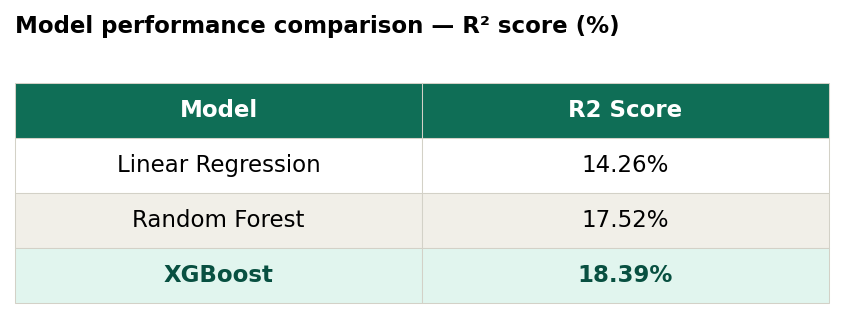

Saved to figures/model_table.png


In [795]:
fig, ax = plt.subplots(figsize=(7, 2.2))
ax.axis('off')

# Round your values to 2 decimal places for clean display
Model_outcome_display = Model_outcome.copy()
Model_outcome_display['R2 Score'] = Model_outcome_display['R2 Score'].round(2).astype(str) + '%'

tbl = ax.table(
    cellText  = Model_outcome_display.values,
    colLabels = Model_outcome_display.columns,
    cellLoc   = 'center',
    loc       = 'center'
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 2.2)

# Header row — dark green
for col in range(len(Model_outcome_display.columns)):
    tbl[0, col].set_facecolor('#0F6E56')
    tbl[0, col].set_text_props(color='white', fontweight='bold')
    tbl[0, col].set_edgecolor('#085041')

# Alternating row colours
for row in range(1, len(Model_outcome_display) + 1):
    for col in range(len(Model_outcome_display.columns)):
        if row % 2 == 0:
            tbl[row, col].set_facecolor('#F1EFE8')

# Highlight the best performing model (highest R2)
best_row = Model_outcome['R2 Score'].idxmax() + 1  # +1 because row 0 is header
for col in range(len(Model_outcome_display.columns)):
    tbl[best_row, col].set_facecolor('#E1F5EE')
    tbl[best_row, col].set_text_props(color='#085041', fontweight='bold')

# Cell borders
for key, cell in tbl.get_celld().items():
    cell.set_edgecolor('#D3D1C7')
    cell.set_linewidth(0.5)

ax.set_title('Model performance comparison — R² score (%)',
             fontsize=11, fontweight='bold',
             loc='left', pad=16)

plt.savefig('/Users/macbook/Desktop/Poster images/model_table.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved to figures/model_table.png")

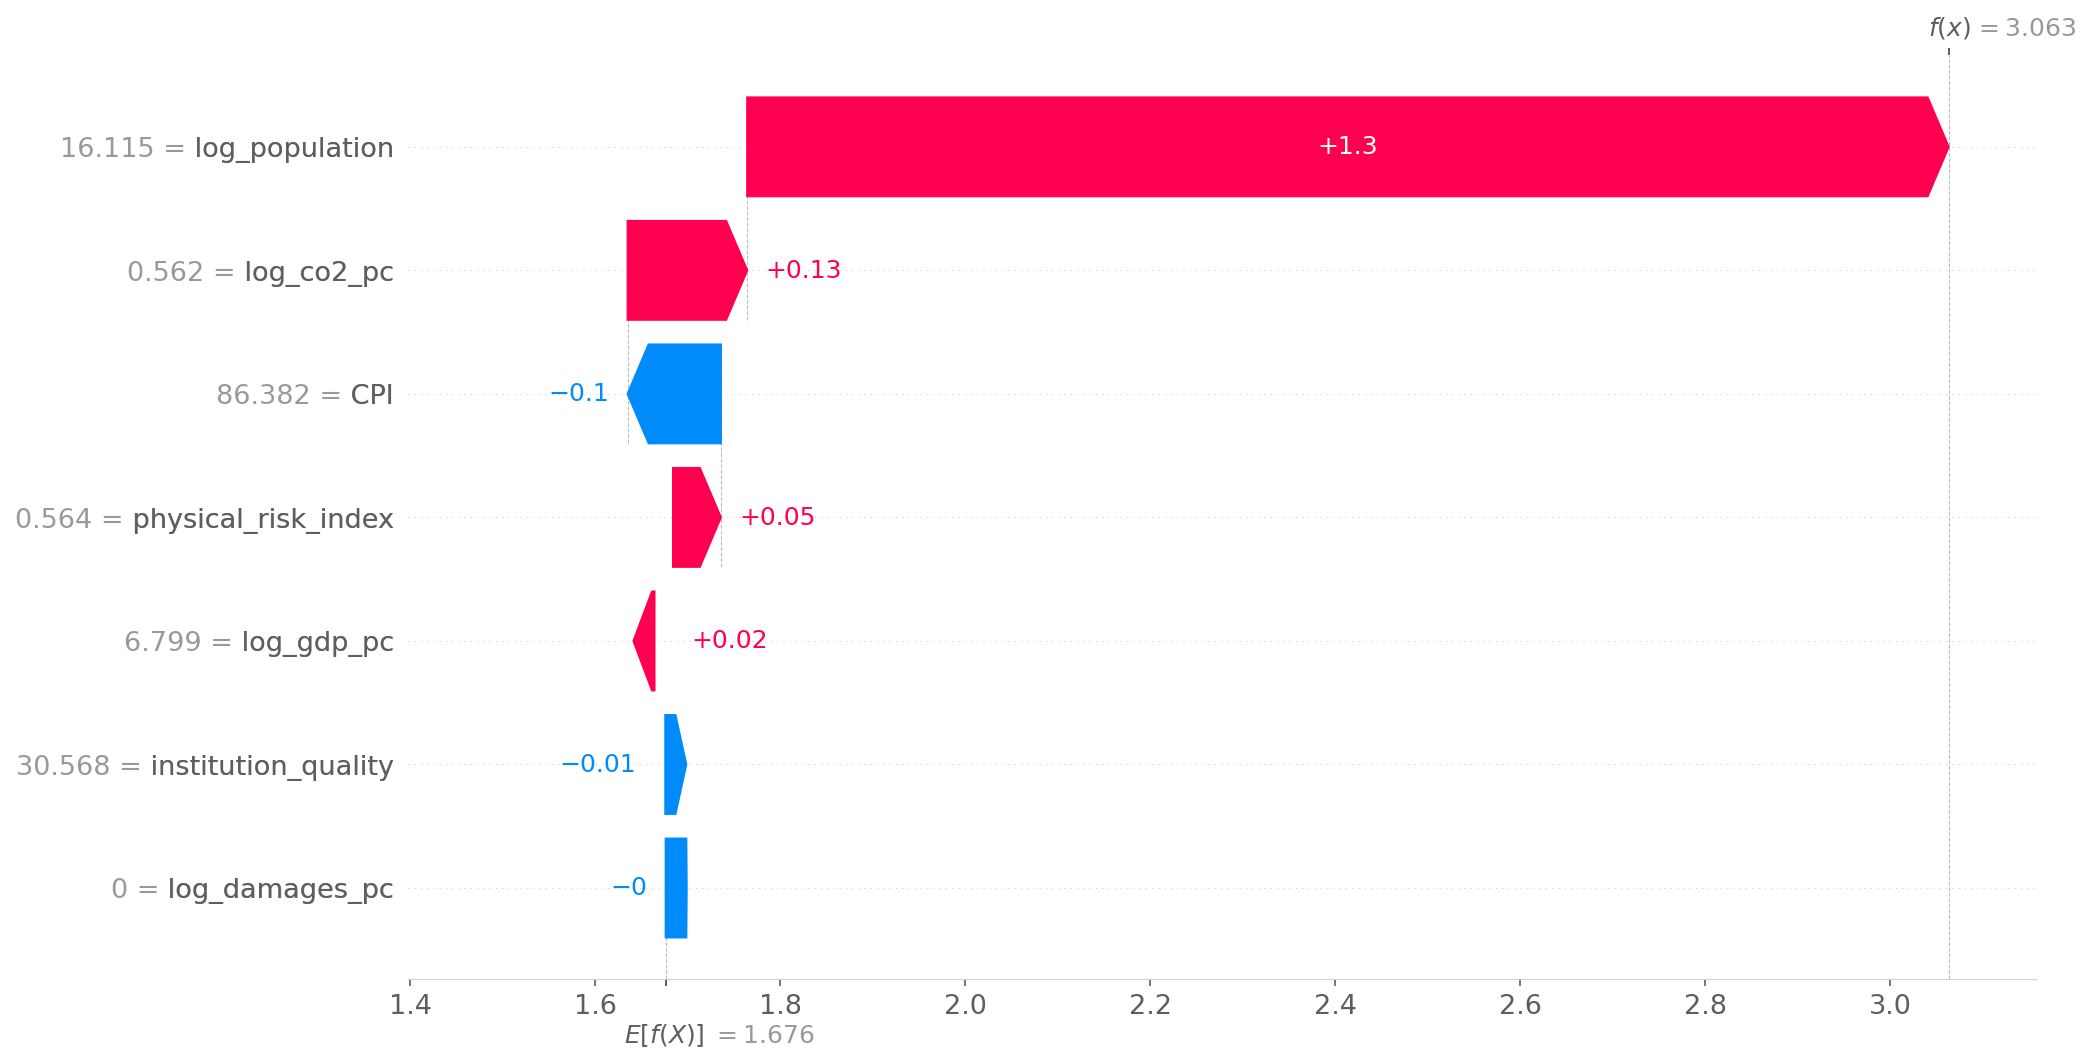

In [801]:
shap.plots.waterfall(shap_values[0], show=False, max_display=10)

fig = plt.gcf()
fig.set_size_inches(14, 8)           # wider and taller
fig.savefig('/Users/macbook/Desktop/Poster images/shap.png',
            dpi=600,                 # higher resolution for print
            bbox_inches='tight',
            facecolor='white')

plt.show()